In [ ]:

import subprocess, sys

_pkgs = [
    "sentence-transformers==3.3.1",
    "faiss-cpu",
    "rank-bm25",
    "transformers>=4.40.0",
    "datasets",
    "scikit-learn",
    "matplotlib",
    "seaborn",
    "tqdm",
    "pandas",
    "numpy",
    "accelerate",
    "scipy",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + _pkgs)
print(" All packages installed")


 All packages installed


In [ ]:

import os, sys
from pathlib import Path

IS_COLAB = "google.colab" in sys.modules

if IS_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive"
else:
    DRIVE_ROOT = os.environ.get("DRIVE_ROOT", "/content/drive/MyDrive")
    print("Colab not detected. Using DRIVE_ROOT =", DRIVE_ROOT)

PAN_DRIVE_DIR_CANDIDATES = [
    f"{DRIVE_ROOT}/PAN2025",
    f"{DRIVE_ROOT}",
]

PAN_DRIVE_DIR = PAN_DRIVE_DIR_CANDIDATES[0]
for cand in PAN_DRIVE_DIR_CANDIDATES:
    if (Path(f"{cand}/pan25-generated-plagiarism-detection-train.zip").exists() or
            Path(f"{cand}/pan25-generated-plagiarism-detection-validation.zip").exists()):
        PAN_DRIVE_DIR = cand
        break

PAN_TRAIN_ZIP       = f"{PAN_DRIVE_DIR}/pan25-generated-plagiarism-detection-train.zip"
PAN_VAL_ZIP         = f"{PAN_DRIVE_DIR}/pan25-generated-plagiarism-detection-validation.zip"
PAN_SPOT_LOCAL_ZIP  = "/content/pan25-generated-plagiarism-detection-spot-check.zip"
QQP_LOCAL_OUTER_ZIP = "/content/quora-question-pairs.zip"
QQP_LOCAL_INNER_ZIP = "/content/train.csv.zip"
QQP_LOCAL_CSV       = "/content/train.csv"

print("Configured paths")
print("-" * 70)
print(f"PAN drive dir      : {PAN_DRIVE_DIR}")
print(f"PAN train zip      : {PAN_TRAIN_ZIP}  exists={Path(PAN_TRAIN_ZIP).exists()}")
print(f"PAN val zip        : {PAN_VAL_ZIP}  exists={Path(PAN_VAL_ZIP).exists()}")
print(f"PAN spot local     : {PAN_SPOT_LOCAL_ZIP}  exists={Path(PAN_SPOT_LOCAL_ZIP).exists()}")
print(f"QQP outer zip      : {QQP_LOCAL_OUTER_ZIP}  exists={Path(QQP_LOCAL_OUTER_ZIP).exists()}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Configured paths
----------------------------------------------------------------------
PAN drive dir      : /content/drive/MyDrive
PAN train zip      : /content/drive/MyDrive/pan25-generated-plagiarism-detection-train.zip  exists=True
PAN val zip        : /content/drive/MyDrive/pan25-generated-plagiarism-detection-validation.zip  exists=True
PAN spot local     : /content/pan25-generated-plagiarism-detection-spot-check.zip  exists=True
QQP outer zip      : /content/quora-question-pairs.zip  exists=True


In [ ]:
#  Imports and global configuration
import os, sys, json, zipfile, re, csv, time, pickle, shutil, warnings
import xml.etree.ElementTree as ET
from pathlib import Path
from copy import deepcopy
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import (precision_recall_fscore_support,
                             average_precision_score, roc_auc_score,
                             precision_recall_curve)

import torch
warnings.filterwarnings("ignore")

#  Reproducibility 
SEED = 42
import random
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Experiment configuration
CFG = {
    # Dataset sizes
    "pan_train_max_pairs" : 500,
    "pan_val_max_pairs"   : 150,
    "qqp_max_pairs"       : 50_000,
    # Chunking
    "chunk_size"          : 128,
    "chunk_stride"        : 64,
    "top_k"               : 10,
    # Models
    "bi_encoder_model"    : "sentence-transformers/all-MiniLM-L6-v2",
    "cross_encoder_model" : "cross-encoder/ms-marco-MiniLM-L-6-v2",
    # Training
    "qqp_epochs"          : 2,
    "pan_bi_epochs"       : 2,
    "ce_epochs"           : 2,
    "batch_size"          : 32,
    "ce_batch_size"       : 32,
    "learning_rate"       : 2e-5,

    "ce_threshold"        : 0.5,
    "span_merge_gap"      : 50,
    # Paths
    "device"              : "cuda" if torch.cuda.is_available() else "cpu",
    "ckpt_dir"            : "/content/bece_ckpts",
    "figure_dir"             : "/content/bece_figures",
    "results_dir"         : "/content/bece_results",
    "model_dir"           : "/content/bece_models",
}

for d in ["ckpt_dir", "figure_dir", "results_dir", "model_dir"]:
    Path(CFG[d]).mkdir(parents=True, exist_ok=True)

print(f"Device : {CFG['device']}")
if CFG["device"] == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Seed   : {SEED}")
print(f"Ckpts  : {CFG['ckpt_dir']}")

TIMING = {}
RESULTS = {}


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB
Seed   : 42
Ckpts  : /content/bece_ckpts


In [ ]:

import time

def ckpt_path(name):
    return Path(CFG["ckpt_dir"]) / f"{name}.pkl"

def save_ckpt(name, obj):
    with open(ckpt_path(name), "wb") as f:
        pickle.dump(obj, f, protocol=4)
    size_mb = ckpt_path(name).stat().st_size / 1e6
    print(f"   Checkpoint saved  [{name}]  ({size_mb:.1f} MB)")

def load_ckpt(name):
    p = ckpt_path(name)
    if p.exists():
        with open(p, "rb") as f:
            obj = pickle.load(f)
        size_mb = p.stat().st_size / 1e6
        print(f"   Checkpoint loaded [{name}]  ({size_mb:.1f} MB)")
        return obj
    return None

def has_ckpt(name):
    return ckpt_path(name).exists()

def save_results(name, d):
    p = Path(CFG["results_dir"]) / f"{name}.json"
    with open(p, "w") as f:
        json.dump(d, f, indent=2, default=str)
    print(f"   Results saved [{name}]")

def savefig(name, fig=None, dpi=150):
    p = Path(CFG["figure_dir"]) / f"{name}.png"
    (fig or plt).savefig(p, dpi=dpi, bbox_inches="tight")
    print(f"   Figure saved  [{name}.png]")
    plt.show()

class Timer:
    def __init__(self, stage):
        self.stage = stage
    def __enter__(self):
        self._t = time.time()
        print(f"\n  [{self.stage}] ")
        return self
    def __exit__(self, *_):
        elapsed = time.time() - self._t
        TIMING[self.stage] = elapsed
        print(f"  [{self.stage}] done in {elapsed/60:.1f} min")

print(" Checkpoint utilities ready")


 Checkpoint utilities ready


In [ ]:
# PAN XML and archive parsing functions


def discover_pan_layout(zip_path: str) -> dict:
    with zipfile.ZipFile(zip_path) as zf:
        names = zf.namelist()
    pairs_candidates = [n for n in names if n.endswith("/pairs") or n.endswith("pairs")]
    if not pairs_candidates:
        raise FileNotFoundError(f"No PAN pairs file found inside {zip_path}")
    pairs_path = sorted(pairs_candidates, key=len)[0]
    text_root  = pairs_path.rsplit("/", 1)[0]
    truth_candidates = [n for n in names if n.endswith(".xml")]
    if not truth_candidates:
        raise FileNotFoundError(f"No truth XML found inside {zip_path}")
    truth_root = sorted({"/".join(n.split("/")[:-1]) for n in truth_candidates}, key=len)[0]
    return {"zip_path": zip_path, "pairs_path": pairs_path,
            "text_root": text_root, "truth_root": truth_root}


def parse_pan_truth_xml(xml_bytes: bytes) -> dict:
    root       = ET.fromstring(xml_bytes)
    doc_ref    = root.attrib.get("reference")
    plagiarism = []
    altered    = []
    meta       = {}
    for feat in root.findall("feature"):
        name  = feat.attrib.get("name", "")
        attrs = dict(feat.attrib)
        if name == "plagiarism":
            plagiarism.append({
                "this_offset"    : int(attrs.get("this_offset",    0)),
                "this_length"    : int(attrs.get("this_length",    0)),
                "this_end"       : int(attrs.get("this_offset",    0)) + int(attrs.get("this_length", 0)),
                "source_reference": attrs.get("source_reference"),
                "source_offset"  : int(attrs.get("source_offset",  0)),
                "source_length"  : int(attrs.get("source_length",  0)),
                "source_end"     : int(attrs.get("source_offset",  0)) + int(attrs.get("source_length", 0)),
                "llm"            : attrs.get("llm"),
                "type"           : attrs.get("type"),
                "obfuscation"    : attrs.get("obfuscation"),
            })
        elif name == "altered":
            altered.append({
                "this_offset"  : int(attrs.get("this_offset", 0)),
                "this_length"  : int(attrs.get("this_length", 0)),
                "this_end"     : int(attrs.get("this_offset", 0)) + int(attrs.get("this_length", 0)),
                "llm"          : attrs.get("llm"),
                "type"         : attrs.get("type"),
            })
        else:
            meta.setdefault(name, []).append(attrs)
    return {"document_reference": doc_ref, "plagiarism": plagiarism,
            "altered": altered, "meta": meta}


def read_text_from_zip(zf, inner_path: str) -> str:
    return zf.read(inner_path).decode("utf-8", errors="ignore")


def build_truth_xml_name(susp_name: str, src_name: str) -> str:
    return f"{Path(susp_name).stem}-{Path(src_name).stem}.xml"


def load_pan_records_from_zip(zip_path: str, split_name: str,
                              max_pairs: int | None = None) -> list:
    layout = discover_pan_layout(zip_path)
    records = []
    with zipfile.ZipFile(zip_path) as zf:
        pairs_lines = read_text_from_zip(zf, layout["pairs_path"]).splitlines()
        pairs       = [line.strip().split() for line in pairs_lines if line.strip()]
        if max_pairs is not None:
            pairs = pairs[:max_pairs]
        nameset = set(zf.namelist())
        for susp_name, src_name in tqdm(pairs, desc=f"Loading PAN {split_name}"):
            xml_name = build_truth_xml_name(susp_name, src_name)
            xml_path  = f'{layout["truth_root"]}/{xml_name}'
            susp_path = f'{layout["text_root"]}/susp/{susp_name}'
            src_path  = f'{layout["text_root"]}/src/{src_name}'
            if xml_path in nameset:
                truth = parse_pan_truth_xml(zf.read(xml_path))
            else:
                truth = {"document_reference": susp_name,
                         "plagiarism": [], "altered": [], "meta": {}}
            susp_text = read_text_from_zip(zf, susp_path)
            src_text  = read_text_from_zip(zf, src_path)
            pair_id   = f"{Path(susp_name).stem}__{Path(src_name).stem}"
            records.append({
                "pair_id"             : pair_id,
                "split"               : split_name,
                "zip_path"            : zip_path,
                "susp_name"           : susp_name,
                "src_name"            : src_name,
                "susp_text"           : susp_text,
                "src_text"            : src_text,
                "plagiarism_spans"    : truth["plagiarism"],
                "altered_spans"       : truth["altered"],
                "num_plagiarism_spans": len(truth["plagiarism"]),
                "num_altered_spans"   : len(truth["altered"]),
            })
    return records

print(" PAN parsing functions defined")


 PAN parsing functions defined


In [ ]:
# Load PAN dataset
with Timer("PAN-data-load"):
    if has_ckpt("pan_train"):
        pan_train = load_ckpt("pan_train")
    else:
        pan_train = load_pan_records_from_zip(
            PAN_TRAIN_ZIP, "train", CFG["pan_train_max_pairs"])
        save_ckpt("pan_train", pan_train)

    if has_ckpt("pan_val"):
        pan_val = load_ckpt("pan_val")
    else:

        val_zip = PAN_VAL_ZIP if Path(PAN_VAL_ZIP).exists() else PAN_SPOT_LOCAL_ZIP
        pan_val = load_pan_records_from_zip(
            val_zip, "validation", CFG["pan_val_max_pairs"])
        save_ckpt("pan_val", pan_val)

print(f"\nPAN train : {len(pan_train):4d} pairs")
print(f"PAN val   : {len(pan_val):4d} pairs")
print(f"  Train pairs with plagiarism : {sum(r['num_plagiarism_spans']>0 for r in pan_train)}")
print(f"  Train pairs with altered    : {sum(r['num_altered_spans']>0 for r in pan_train)}")
print(f"  Val pairs with plagiarism   : {sum(r['num_plagiarism_spans']>0 for r in pan_val)}")



  [PAN-data-load] 
   Checkpoint loaded [pan_train]  (70.1 MB)
   Checkpoint loaded [pan_val]  (21.2 MB)
  [PAN-data-load] done in 0.0 min

PAN train :  500 pairs
PAN val   :  150 pairs
  Train pairs with plagiarism : 360
  Train pairs with altered    : 259
  Val pairs with plagiarism   : 107


In [ ]:
# Load QQP (with leakage-safe splits by question ID)

def extract_qqp_csv():
    """Auto-extract QQP from zip if csv not present."""
    if Path(QQP_LOCAL_CSV).exists():
        return
    if Path(QQP_LOCAL_OUTER_ZIP).exists():
        print("Extracting outer QQP zip …")
        with zipfile.ZipFile(QQP_LOCAL_OUTER_ZIP) as zf:
            zf.extractall("/content/")
    inner = "/content/train.csv.zip"
    if Path(inner).exists():
        with zipfile.ZipFile(inner) as zf:
            zf.extractall("/content/")
    elif Path(QQP_LOCAL_INNER_ZIP).exists():
        with zipfile.ZipFile(QQP_LOCAL_INNER_ZIP) as zf:
            zf.extractall("/content/")
    if not Path(QQP_LOCAL_CSV).exists():
        raise FileNotFoundError(
            "train.csv not found. Please upload quora-question-pairs.zip "
            "or train.csv to /content/ via Files panel.")

def load_qqp_with_leakage_safe_split(csv_path, max_pairs=50_000,
                                      val_ratio=0.1, seed=42):
    """
    Load QQP and create leakage-safe train/val splits.
    Any question ID that appears in multiple pairs is confined to one split.
    """
    rng = random.Random(seed)
    records = []
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if len(records) >= max_pairs:
                break
            try:
                records.append({
                    "qid1": int(row["qid1"]),
                    "qid2": int(row["qid2"]),
                    "q1"  : row["question1"].strip(),
                    "q2"  : row["question2"].strip(),
                    "label": int(row["is_duplicate"]),
                })
            except (ValueError, KeyError):
                continue

    # Leakage-safe split: group by qid1 buckets
    all_qids = list({r["qid1"] for r in records})
    rng.shuffle(all_qids)
    n_val = int(len(all_qids) * val_ratio)
    val_qids = set(all_qids[:n_val])

    qqp_train = [r for r in records if r["qid1"] not in val_qids]
    qqp_val   = [r for r in records if r["qid1"] in val_qids]
    return qqp_train, qqp_val

with Timer("QQP-load"):
    if has_ckpt("qqp_train") and has_ckpt("qqp_val"):
        qqp_train = load_ckpt("qqp_train")
        qqp_val   = load_ckpt("qqp_val")
    else:
        extract_qqp_csv()
        qqp_train, qqp_val = load_qqp_with_leakage_safe_split(
            QQP_LOCAL_CSV, CFG["qqp_max_pairs"])
        save_ckpt("qqp_train", qqp_train)
        save_ckpt("qqp_val",   qqp_val)

print(f"\nQQP train : {len(qqp_train):6d} pairs  "
      f"({sum(r['label'] for r in qqp_train):6d} duplicates)")
print(f"QQP val   : {len(qqp_val):6d} pairs  "
      f"({sum(r['label'] for r in qqp_val):6d} duplicates)")



  [QQP-load] 
   Checkpoint loaded [qqp_train]  (6.7 MB)
   Checkpoint loaded [qqp_val]  (0.7 MB)
  [QQP-load] done in 0.0 min

QQP train :  44985 pairs  ( 16752 duplicates)
QQP val   :   5015 pairs  (  1897 duplicates)


   Figure saved  [01_dataset_eda.png]


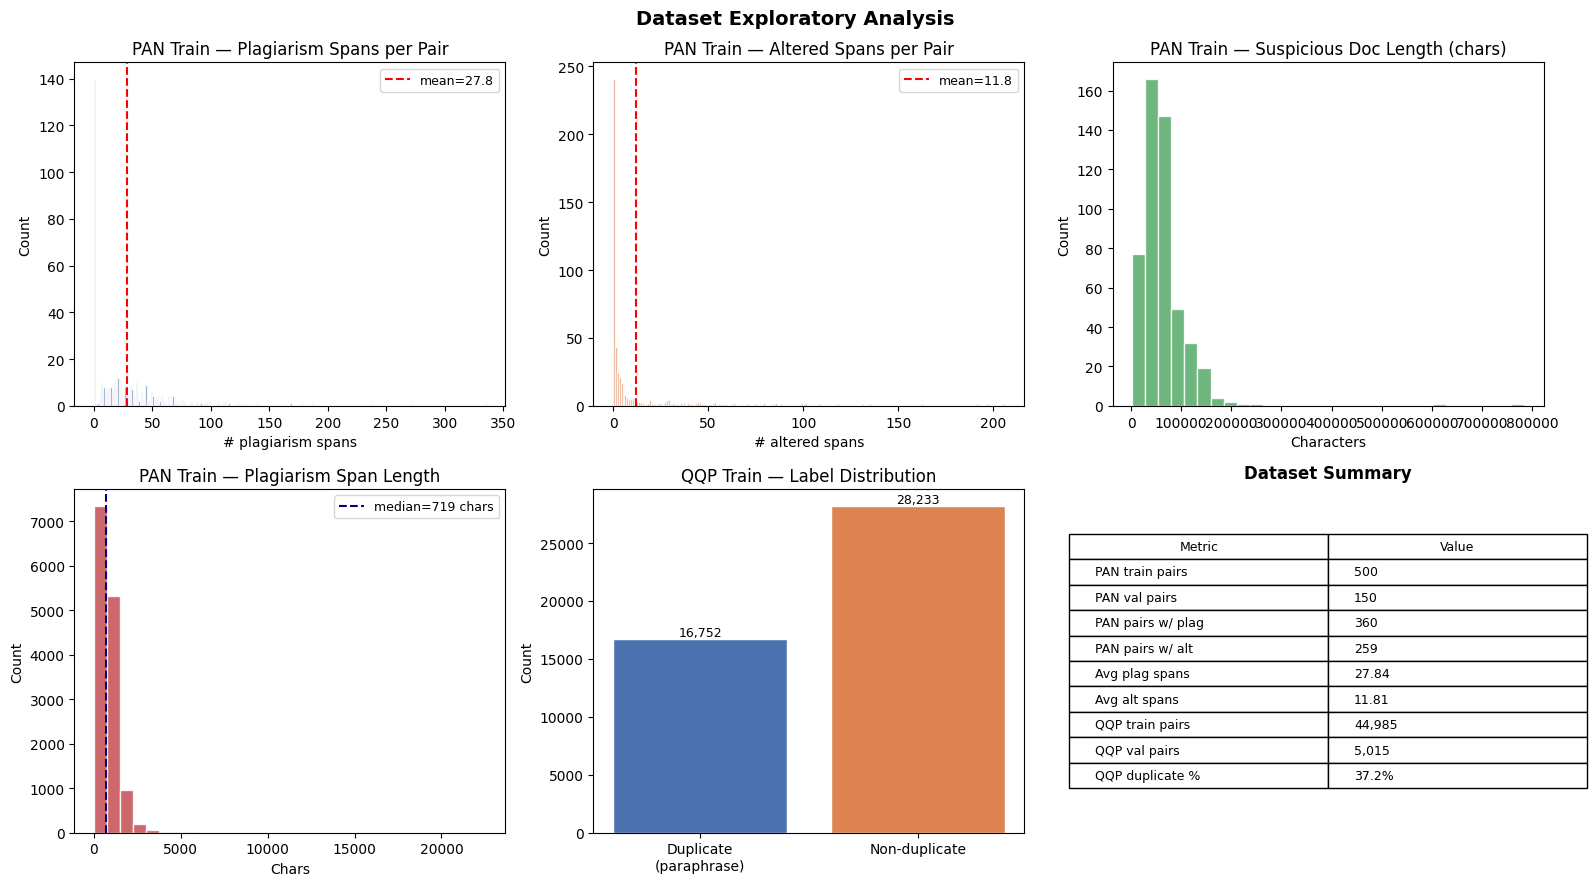


Dataset summary saved.


In [ ]:
# Dataset Exploratory Analysis
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Dataset Exploratory Analysis", fontsize=14, fontweight="bold")

#  PAN: plagiarism spans per pair
ax = axes[0, 0]
n_spans = [r["num_plagiarism_spans"] for r in pan_train]
ax.hist(n_spans, bins=range(0, max(n_spans)+2), color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Plagiarism Spans per Pair")
ax.set_xlabel("# plagiarism spans"); ax.set_ylabel("Count")
ax.axvline(np.mean(n_spans), color="red", ls="--",
           label=f"mean={np.mean(n_spans):.1f}")
ax.legend(fontsize=9)

#  PAN: altered spans per pair
ax = axes[0, 1]
n_alt = [r["num_altered_spans"] for r in pan_train]
ax.hist(n_alt, bins=range(0, max(n_alt)+2), color="#DD8452", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Altered Spans per Pair")
ax.set_xlabel("# altered spans"); ax.set_ylabel("Count")
ax.axvline(np.mean(n_alt), color="red", ls="--",
           label=f"mean={np.mean(n_alt):.1f}")
ax.legend(fontsize=9)

# PAN: suspicious doc lengths (chars)
ax = axes[0, 2]
susp_lens = [len(r["susp_text"]) for r in pan_train]
ax.hist(susp_lens, bins=30, color="#55A868", edgecolor="white", alpha=0.85)
ax.set_title("PAN Train — Suspicious Doc Length (chars)")
ax.set_xlabel("Characters"); ax.set_ylabel("Count")

# PAN: plagiarism span length distribution
ax = axes[1, 0]
span_lens = [s["this_length"]
             for r in pan_train for s in r["plagiarism_spans"]]
if span_lens:
    ax.hist(span_lens, bins=30, color="#C44E52", edgecolor="white", alpha=0.85)
    ax.axvline(np.median(span_lens), color="navy", ls="--",
               label=f"median={np.median(span_lens):.0f} chars")
ax.set_title("PAN Train — Plagiarism Span Length")
ax.set_xlabel("Chars"); ax.set_ylabel("Count")
ax.legend(fontsize=9)

#  QQP: label distribution
ax = axes[1, 1]
dup_count  = sum(r["label"] for r in qqp_train)
ndup_count = len(qqp_train) - dup_count
ax.bar(["Duplicate\n(paraphrase)", "Non-duplicate"],
       [dup_count, ndup_count],
       color=["#4C72B0", "#DD8452"], edgecolor="white")
ax.set_title("QQP Train — Label Distribution")
ax.set_ylabel("Count")
for i, v in enumerate([dup_count, ndup_count]):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)

ax = axes[1, 2]
ax.axis("off")
rows = [
    ["PAN train pairs",    f"{len(pan_train):,}"],
    ["PAN val pairs",      f"{len(pan_val):,}"],
    ["PAN pairs w/ plag",  f"{sum(r['num_plagiarism_spans']>0 for r in pan_train):,}"],
    ["PAN pairs w/ alt",   f"{sum(r['num_altered_spans']>0 for r in pan_train):,}"],
    ["Avg plag spans",     f"{np.mean([r['num_plagiarism_spans'] for r in pan_train]):.2f}"],
    ["Avg alt spans",      f"{np.mean([r['num_altered_spans'] for r in pan_train]):.2f}"],
    ["QQP train pairs",    f"{len(qqp_train):,}"],
    ["QQP val pairs",      f"{len(qqp_val):,}"],
    ["QQP duplicate %",    f"{100*dup_count/len(qqp_train):.1f}%"],
]
tbl = ax.table(cellText=rows, colLabels=["Metric", "Value"],
               loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1.2, 1.4)
ax.set_title("Dataset Summary", fontweight="bold", pad=8)

plt.tight_layout()
savefig("01_dataset_eda")
print("\nDataset summary saved.")


In [ ]:
#  Text normalisation
import unicodedata

def normalise_text(text: str) -> str:
    """Light normalisation: unicode NFC, collapse whitespace, strip trailing spaces."""
    text = unicodedata.normalize("NFC", text)
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\r\n?", "\n", text)
    text = "\n".join(line.rstrip() for line in text.splitlines())
    return text.strip()

#  Chunking with character-offset mapping
from transformers import AutoTokenizer

_tokenizer = AutoTokenizer.from_pretrained(CFG["bi_encoder_model"])

def chunk_text_with_offsets(text: str,
                             chunk_size: int = 128,
                             stride: int = 64) -> list:
    """
    Tokenise text and produce overlapping windows.
    Each chunk dict carries:
      text        – decoded chunk text
      char_start  – character start in original text
      char_end    – character end in original text
      tok_start   – token window start index
      tok_end     – token window end index
    """
    enc = _tokenizer(text,
                     return_offsets_mapping=True,
                     truncation=False,
                     add_special_tokens=False)
    ids     = enc["input_ids"]
    offsets = enc["offset_mapping"]

    if not ids:
        return [{"text": text[:512], "char_start": 0,
                 "char_end": len(text), "tok_start": 0, "tok_end": 0}]

    chunks = []
    start  = 0
    while start < len(ids):
        end  = min(start + chunk_size, len(ids))
        c_s  = offsets[start][0]
        c_e  = offsets[end - 1][1]
        chunks.append({
            "text"      : text[c_s:c_e],
            "char_start": c_s,
            "char_end"  : c_e,
            "tok_start" : start,
            "tok_end"   : end,
        })
        if end == len(ids):
            break
        start += stride
    return chunks


def build_chunks_for_pair(record: dict) -> tuple:
    susp_text = normalise_text(record["susp_text"])
    src_text  = normalise_text(record["src_text"])
    susp_chunks = chunk_text_with_offsets(susp_text, CFG["chunk_size"], CFG["chunk_stride"])
    src_chunks  = chunk_text_with_offsets(src_text,  CFG["chunk_size"], CFG["chunk_stride"])
    return susp_chunks, src_chunks


_ex = pan_train[0]
_sc, _rc = build_chunks_for_pair(_ex)
print(f"Example pair: {_ex['pair_id']}")
print(f"  Suspicious: {len(_ex['susp_text']):,} chars → {len(_sc)} chunks")
print(f"  Source    : {len(_ex['src_text']):,} chars → {len(_rc)} chunks")
print(f"  First susp chunk [{_sc[0]['char_start']}-{_sc[0]['char_end']}]: \"{_sc[0]['text'][:80]}...\"")


Token indices sequence length is longer than the specified maximum sequence length for this model (5488 > 512). Running this sequence through the model will result in indexing errors


Example pair: suspicious-document020468__source-document020468
  Suspicious: 22,260 chars → 85 chunks
  Source    : 77,555 chars → 331 chunks
  First susp chunk [0-742]: "Quest for HI Turbulence Statistics: New Techniques

By A. Lazarian and D. Pogosy..."


In [ ]:
#  Build chunk datasets
def build_chunk_dataset(records, desc="chunks"):
    """Return list of dicts with pair-level metadata + chunk arrays."""
    result = []
    for r in tqdm(records, desc=desc):
        susp_chunks, src_chunks = build_chunks_for_pair(r)
        result.append({
            "pair_id"          : r["pair_id"],
            "susp_chunks"      : susp_chunks,
            "src_chunks"       : src_chunks,
            "plagiarism_spans" : r["plagiarism_spans"],
            "altered_spans"    : r["altered_spans"],
        })
    return result

with Timer("chunking"):
    if has_ckpt("chunk_train") and has_ckpt("chunk_val"):
        chunk_train = load_ckpt("chunk_train")
        chunk_val   = load_ckpt("chunk_val")
    else:
        chunk_train = build_chunk_dataset(pan_train, "chunk train")
        chunk_val   = build_chunk_dataset(pan_val,   "chunk val")
        save_ckpt("chunk_train", chunk_train)
        save_ckpt("chunk_val",   chunk_val)

total_susp = sum(len(r["susp_chunks"]) for r in chunk_train)
total_src  = sum(len(r["src_chunks"])  for r in chunk_train)
print(f"\nTrain — suspicious chunks: {total_susp:,}")
print(f"Train — source chunks     : {total_src:,}")
print(f"Val   — suspicious chunks : {sum(len(r['susp_chunks']) for r in chunk_val):,}")


def chunk_overlaps_span(chunk_start, chunk_end, span_start, span_end):
    return chunk_start < span_end and chunk_end > span_start

def get_positive_chunk_pairs(pair_record):
    """Return (susp_chunk_idx, src_chunk_idx) pairs that overlap a plagiarism span."""
    positives = []
    for si, sc in enumerate(pair_record["susp_chunks"]):
        for plag in pair_record["plagiarism_spans"]:
            if chunk_overlaps_span(sc["char_start"], sc["char_end"],
                                   plag["this_offset"], plag["this_end"]):
                for ri, rc in enumerate(pair_record["src_chunks"]):
                    if chunk_overlaps_span(rc["char_start"], rc["char_end"],
                                           plag["source_offset"], plag["source_end"]):
                        positives.append((si, ri))
    return list(set(positives))

print("\nChunk-level positive pair counts:")
pos_counts = [len(get_positive_chunk_pairs(r)) for r in chunk_train]
print(f"  Mean: {np.mean(pos_counts):.1f}  Max: {max(pos_counts)}  "
      f"Total: {sum(pos_counts):,}")



  [chunking] 
   Checkpoint loaded [chunk_train]  (150.1 MB)
   Checkpoint loaded [chunk_val]  (45.5 MB)
  [chunking] done in 0.0 min

Train — suspicious chunks: 171,917
Train — source chunks     : 200,867
Val   — suspicious chunks : 53,681

Chunk-level positive pair counts:
  Mean: 1547.6  Max: 37435  Total: 773,798


In [ ]:
# baselines evaluation utilities
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_chunk_classifier(pair_records, pred_fn, threshold=0.5,
                               desc="eval", top_k=None):
    """
    Evaluate a chunk-level retrieval / scoring function.
    pred_fn(susp_chunk_text, src_chunks) → list of (score, src_chunk_idx)
    Returns dict of metrics.
    """
    all_y_true, all_y_pred, all_scores = [], [], []
    recall_at_k = []

    for pr in tqdm(pair_records, desc=desc, leave=False):
        positives = set(ri for _, ri in get_positive_chunk_pairs(pr))
        if not positives and not pr["plagiarism_spans"]:
            # No plagiarism in this pair
            for sc in pr["susp_chunks"]:
                scored = pred_fn(sc["text"], pr["src_chunks"])
                for score, ri in scored:
                    all_y_true.append(0)
                    all_y_pred.append(int(score >= threshold))
                    all_scores.append(score)
            continue

        pos_set_by_susp = defaultdict(set)
        for si, ri in get_positive_chunk_pairs(pr):
            pos_set_by_susp[si].add(ri)

        for si, sc in enumerate(pr["susp_chunks"]):
            scored = pred_fn(sc["text"], pr["src_chunks"])
            gt_pos = pos_set_by_susp[si]
            # Recall@K
            top_k_val = top_k or CFG["top_k"]
            retrieved_top = {ri for _, ri in scored[:top_k_val]}
            if gt_pos:
                recall_at_k.append(len(gt_pos & retrieved_top) / len(gt_pos))
            for score, ri in scored:
                all_y_true.append(1 if ri in gt_pos else 0)
                all_y_pred.append(int(score >= threshold))
                all_scores.append(score)

    if not all_y_true:
        return {}
    try:
        auc = roc_auc_score(all_y_true, all_scores)
    except Exception:
        auc = float("nan")
    return {
        "precision"   : precision_score(all_y_true, all_y_pred, zero_division=0),
        "recall"      : recall_score(all_y_true, all_y_pred, zero_division=0),
        "f1"          : f1_score(all_y_true, all_y_pred, zero_division=0),
        "auroc"       : auc,
        "recall_at_k" : float(np.mean(recall_at_k)) if recall_at_k else float("nan"),
    }

print(" Evaluation utilities defined")


 Evaluation utilities defined


In [ ]:
#  TF-IDF baseline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json

def build_tfidf_scorer(src_chunks: list):
    texts = [c["text"] for c in src_chunks]
    vec   = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5),
        max_features=20_000, sublinear_tf=True)
    src_mat = vec.fit_transform(texts)
    def score_fn(susp_text, _):
        q_vec = vec.transform([susp_text])
        sims  = cosine_similarity(q_vec, src_mat)[0]
        return sorted(zip(sims.tolist(), range(len(src_chunks))),
                      key=lambda x: -x[0])
    return score_fn

# Tune threshold on val pairs
with Timer("TF-IDF tuning"):
    best_f1, best_thresh = 0.0, 0.5
    if has_ckpt("tfidf_best_thresh") and has_ckpt("tfidf_best_f1"):
        best_f1 = load_ckpt("tfidf_best_f1")
        best_thresh = load_ckpt("tfidf_best_thresh")
        print(f"  Loaded best TF-IDF threshold: {best_thresh}  F1={best_f1:.4f}")
    else:

        sample_val = chunk_val[:50]
        for thresh in [0.1, 0.2, 0.3]:
            metrics = evaluate_chunk_classifier(
                sample_val,
                lambda txt, srcs: (build_tfidf_scorer(srcs))(txt, srcs),
                threshold=thresh, desc=f"tfidf-tune-{thresh:.1f}")
            if metrics and metrics["f1"] > best_f1:
                best_f1, best_thresh = metrics["f1"], thresh
        save_ckpt("tfidf_best_f1", best_f1)
        save_ckpt("tfidf_best_thresh", best_thresh)
    print(f"  Best TF-IDF threshold (sample): {best_thresh}  F1={best_f1:.4f}")

with Timer("TF-IDF eval"):
    tfidf_json_path = Path(CFG["results_dir"]) / "baseline_tfidf.json"
    tfidf_metrics = {}
    if tfidf_json_path.exists():
        try:
            with open(tfidf_json_path, "r") as f:
                tfidf_metrics = json.load(f)
            print(f"   Loaded TF-IDF metrics from JSON file [{tfidf_json_path}]")
        except json.JSONDecodeError:
            print(f"   Error decoding JSON from [{tfidf_json_path}]. Re-evaluating...")
            if has_ckpt("baseline_tfidf_metrics"):
                tfidf_metrics = load_ckpt("baseline_tfidf_metrics")
                print("   Loaded TF-IDF metrics from checkpoint.")
            else:
                tfidf_metrics = evaluate_chunk_classifier(
                    chunk_val,
                    lambda txt, srcs: (build_tfidf_scorer(srcs))(txt, srcs),
                    threshold=best_thresh, desc="TF-IDF eval")
                save_ckpt("baseline_tfidf_metrics", tfidf_metrics)
    elif has_ckpt("baseline_tfidf_metrics"):
        tfidf_metrics = load_ckpt("baseline_tfidf_metrics")
        print("   Loaded TF-IDF metrics from checkpoint.")
    else:
        tfidf_metrics = evaluate_chunk_classifier(
            chunk_val,
            lambda txt, srcs: (build_tfidf_scorer(srcs))(txt, srcs),
            threshold=best_thresh, desc="TF-IDF eval")
        save_ckpt("baseline_tfidf_metrics", tfidf_metrics)

RESULTS["B1_TFIDF"] = tfidf_metrics
print("  TF-IDF:", {k: f"{v:.4f}" for k, v in tfidf_metrics.items()})
save_results("baseline_tfidf", tfidf_metrics)



  [TF-IDF tuning] 


  Best TF-IDF threshold (sample): 0.3  F1=0.2176
  [TF-IDF tuning] done in 248.1 min

  [TF-IDF eval] 


  [TF-IDF eval] done in 288.4 min
  TF-IDF: {'precision': '0.2196', 'recall': '0.2832', 'f1': '0.2474', 'auroc': '0.8531', 'recall_at_k': '0.4225'}
   Results saved [baseline_tfidf]


In [ ]:
#  BM25 baseline
from rank_bm25 import BM25Okapi

def tokenize_for_bm25(text: str) -> list:
    return text.lower().split()

def build_bm25_scorer(src_chunks: list):
    corpus  = [tokenize_for_bm25(c["text"]) for c in src_chunks]
    bm25    = BM25Okapi(corpus)
    def score_fn(susp_text, _):
        query  = tokenize_for_bm25(susp_text)
        scores = bm25.get_scores(query)
        # Normalise to [0, 1]
        mx = max(scores) if max(scores) > 0 else 1.0
        normed = (scores / mx).tolist()
        return sorted(zip(normed, range(len(src_chunks))), key=lambda x: -x[0])
    return score_fn

with Timer("BM25 eval"):
    bm25_metrics = evaluate_chunk_classifier(
        chunk_val,
        lambda txt, srcs: (build_bm25_scorer(srcs))(txt, srcs),
        threshold=0.5, desc="BM25 eval")
    RESULTS["B2_BM25"] = bm25_metrics
    print("  BM25:", {k: f"{v:.4f}" for k, v in bm25_metrics.items()})
save_results("baseline_bm25", bm25_metrics)



  [BM25 eval] 


  BM25: {'precision': '0.0156', 'recall': '0.3574', 'f1': '0.0300', 'auroc': '0.6724', 'recall_at_k': '0.3484'}
  [BM25 eval] done in 15.0 min
   Results saved [baseline_bm25]


In [ ]:
#  sBert baseline
from sentence_transformers import SentenceTransformer

_sbert_model = SentenceTransformer(CFG["bi_encoder_model"], device=CFG["device"])

def build_sbert_scorer(src_chunks: list):
    src_texts = [c["text"] for c in src_chunks]
    src_embs  = _sbert_model.encode(src_texts, normalize_embeddings=True,
                                    show_progress_bar=False, batch_size=64)
    def score_fn(susp_text, _):
        q_emb  = _sbert_model.encode([susp_text], normalize_embeddings=True,
                                      show_progress_bar=False)[0]
        sims   = (src_embs @ q_emb).tolist()
        return sorted(zip(sims, range(len(src_chunks))), key=lambda x: -x[0])
    return score_fn

with Timer("SBERT eval"):
    if has_ckpt("baseline_sbert_metrics"):
        sbert_metrics = load_ckpt("baseline_sbert_metrics")
    else:
        sbert_metrics = evaluate_chunk_classifier(
            chunk_val,
            lambda txt, srcs: (build_sbert_scorer(srcs))(txt, srcs),
            threshold=0.5, desc="SBERT eval")
        save_ckpt("baseline_sbert_metrics", sbert_metrics)
    RESULTS["B3_SBERT"] = sbert_metrics
    print("  SBERT:", {k: f"{v:.4f}" for k, v in sbert_metrics.items()})
save_results("baseline_sbert", sbert_metrics)


  [SBERT eval] 


   Checkpoint saved  [baseline_sbert_metrics]  (0.0 MB)
  SBERT: {'precision': '0.0329', 'recall': '0.5483', 'f1': '0.0621', 'auroc': '0.8163', 'recall_at_k': '0.3544'}
  [SBERT eval] done in 759.9 min
   Results saved [baseline_sbert]


RESULTS keys: ['B1_TFIDF', 'B2_BM25', 'B3_SBERT']
B1_TFIDF {'precision': 0.21964694580401656, 'recall': 0.28320065799136385, 'f1': 0.24740760066464648, 'auroc': 0.8531038187032622, 'recall_at_k': 0.42247607041366825}
B2_BM25 {'precision': 0.015638957617043155, 'recall': 0.35741562141996885, 'f1': 0.02996670229586685, 'auroc': 0.6723713150148476, 'recall_at_k': 0.34836676007275874}
B3_SBERT {'precision': 0.03293044048683515, 'recall': 0.5483065534764856, 'f1': 0.06212948079811497, 'auroc': 0.8162974398286437, 'recall_at_k': 0.3543825020601867}

BASELINE RESULTS (chunk-level, PAN validation set)
     System  Precision  Recall     F1  AUROC   R@10
B1 · TF-IDF     0.2196  0.2832 0.2474 0.8531 0.4225
  B2 · BM25     0.0156  0.3574 0.0300 0.6724 0.3484
 B3 · SBERT     0.0329  0.5483 0.0621 0.8163 0.3544
   Figure saved  [02_baselines.png]


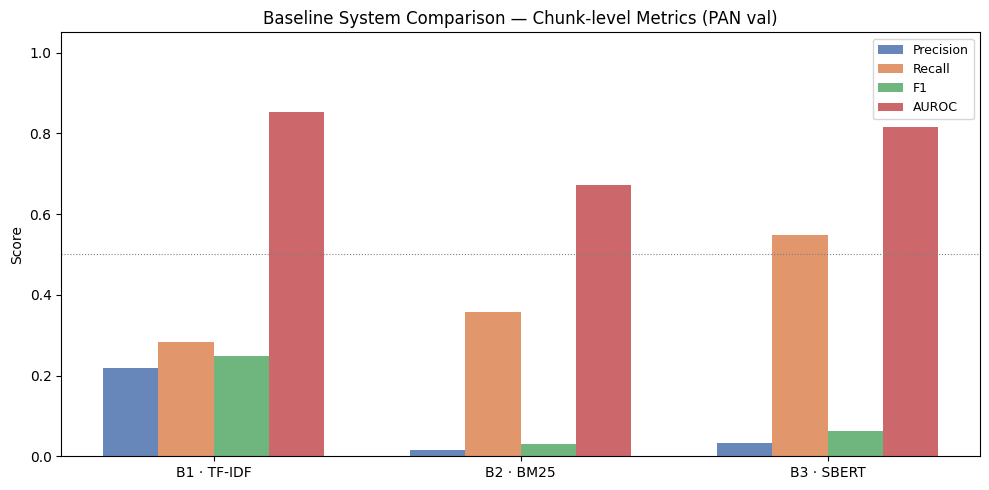

   Results saved [baselines_table]


In [ ]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path("/content/bece_results")

baseline_files = {
    "B1_TFIDF": BASE_DIR / "baseline_tfidf.json",
    "B2_BM25":  BASE_DIR / "baseline_bm25.json",
    "B3_SBERT": BASE_DIR / "baseline_sbert.json",
}

if "RESULTS" not in globals() or not isinstance(RESULTS, dict):
    RESULTS = {}


for sys_key, file_path in baseline_files.items():
    if not file_path.exists():
        print(f"[WARN] File not found: {file_path}")
        RESULTS[sys_key] = {}
        continue

    with open(file_path, "r", encoding="utf-8") as f:
        RESULTS[sys_key] = json.load(f)

print("RESULTS keys:", list(RESULTS.keys()))
for k in baseline_files:
    print(k, RESULTS.get(k, {}))


systems = [
    ("B1 · TF-IDF", "B1_TFIDF"),
    ("B2 · BM25",   "B2_BM25"),
    ("B3 · SBERT",  "B3_SBERT"),
]

metric_keys = ["precision", "recall", "f1", "auroc", "recall_at_k"]

rows = []
for display_name, result_key in systems:
    result = RESULTS.get(result_key, {}) or {}
    rows.append({
        "System": display_name,
        "Precision": result.get("precision", np.nan),
        "Recall": result.get("recall", np.nan),
        "F1": result.get("f1", np.nan),
        "AUROC": result.get("auroc", np.nan),
        f"R@{CFG['top_k']}": result.get("recall_at_k", np.nan),
    })

bl_df = pd.DataFrame(rows)

print("\n" + "=" * 70)
print("BASELINE RESULTS (chunk-level, PAN validation set)")
print("=" * 70)
print(bl_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 70)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(bl_df))
width = 0.18
metrics_to_plot = ["Precision", "Recall", "F1", "AUROC"]
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (m, c) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, bl_df[m], width, label=m, color=c, alpha=0.85)

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(bl_df["System"], fontsize=10)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Baseline System Comparison — Chunk-level Metrics (PAN val)")
ax.legend(fontsize=9)
ax.axhline(0.5, color="gray", ls=":", lw=0.8)

plt.tight_layout()
savefig("02_baselines")
save_results("baselines_table", bl_df.to_dict(orient="records"))

In [ ]:
# Prepare QQP training data for bi-encoder
from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader

def make_qqp_examples(records, max_neg_ratio=1.0, seed=42):
    """
    For MNRL, we only use positive (duplicate) pairs.
    Non-duplicate pairs are used as explicit negative InputExamples
    with label=0 in a contrastive setup, but for MNRL we use only positives
    and rely on in-batch negatives.
    """
    rng = random.Random(seed)
    positives = [InputExample(texts=[r["q1"], r["q2"]])
                 for r in records if r["label"] == 1]
    rng.shuffle(positives)
    return positives

qqp_train_examples = make_qqp_examples(qqp_train)
print(f"QQP positive (duplicate) examples: {len(qqp_train_examples):,}")


QQP positive (duplicate) examples: 16,752


In [ ]:
#  QQP pre-training
BI_ENCODER_QQP_PATH = Path(CFG["model_dir"]) / "bi_encoder_qqp"

with Timer("bi-encoder-QQP-pretrain"):
    if BI_ENCODER_QQP_PATH.exists() and any(BI_ENCODER_QQP_PATH.iterdir()):
        print(f"   Loading pre-trained bi-encoder from {BI_ENCODER_QQP_PATH}")
        bi_encoder = SentenceTransformer(str(BI_ENCODER_QQP_PATH), device=CFG["device"])
    else:
        bi_encoder  = SentenceTransformer(CFG["bi_encoder_model"], device=CFG["device"])
        train_dl    = DataLoader(qqp_train_examples,
                                 shuffle=True,
                                 batch_size=CFG["batch_size"],
                                 drop_last=True)
        loss_fn     = losses.MultipleNegativesRankingLoss(bi_encoder)
        warmup_steps = int(len(train_dl) * CFG["qqp_epochs"] * 0.1)
        bi_encoder.fit(
            train_objectives=[(train_dl, loss_fn)],
            epochs=CFG["qqp_epochs"],
            warmup_steps=warmup_steps,
            optimizer_params={"lr": CFG["learning_rate"]},
            show_progress_bar=True,
            output_path=str(BI_ENCODER_QQP_PATH),
            checkpoint_path=CFG["ckpt_dir"] + "/bi_qqp_ckpt",
            checkpoint_save_steps=len(train_dl),
        )
        print(f"   Bi-encoder (QQP) saved to {BI_ENCODER_QQP_PATH}")

print(f"Bi-encoder embedding dim: {bi_encoder.get_sentence_embedding_dimension()}")



  [bi-encoder-QQP-pretrain] 
   Loading pre-trained bi-encoder from /content/bece_models/bi_encoder_qqp
  [bi-encoder-QQP-pretrain] done in 0.0 min
Bi-encoder embedding dim: 384


In [ ]:
#  Build PAN fine-tuning examples
def build_pan_bi_encoder_examples(chunk_records, seed=42):
    """
    Positive: (susp_chunk, src_chunk) pairs overlapping a plagiarism span.
    Returns list of InputExample(texts=[susp_text, src_text]).
    """
    rng = random.Random(seed)
    examples = []
    for pr in tqdm(chunk_records, desc="PAN positives"):
        positives = get_positive_chunk_pairs(pr)
        for si, ri in positives:
            sc = pr["susp_chunks"][si]
            rc = pr["src_chunks"][ri]
            examples.append(InputExample(texts=[sc["text"], rc["text"]]))
    rng.shuffle(examples)
    print(f"  PAN positive chunk-pair examples: {len(examples):,}")
    return examples

pan_bi_examples = build_pan_bi_encoder_examples(chunk_train)


  PAN positive chunk-pair examples: 773,798


In [ ]:

#  PAN fine-tuning of bi-encoder
BI_ENCODER_PAN_PATH = Path(CFG["model_dir"]) / "bi_encoder_pan"

with Timer("bi-encoder-PAN-finetune"):
    if BI_ENCODER_PAN_PATH.exists() and any(BI_ENCODER_PAN_PATH.iterdir()):
        print(f"   Loading PAN-finetuned bi-encoder from {BI_ENCODER_PAN_PATH}")
        bi_encoder = SentenceTransformer(str(BI_ENCODER_PAN_PATH), device=CFG["device"])
    else:
        # Start from QQP pre-trained model
        bi_encoder = SentenceTransformer(str(BI_ENCODER_QQP_PATH), device=CFG["device"])
        if pan_bi_examples:
            train_dl   = DataLoader(pan_bi_examples,
                                    shuffle=True,
                                    batch_size=CFG["batch_size"],
                                    drop_last=True)
            loss_fn    = losses.MultipleNegativesRankingLoss(bi_encoder)
            warmup_steps = int(len(train_dl) * CFG["pan_bi_epochs"] * 0.1)
            bi_encoder.fit(
                train_objectives=[(train_dl, loss_fn)],
                epochs=CFG["pan_bi_epochs"],
                warmup_steps=warmup_steps,
                optimizer_params={"lr": CFG["learning_rate"]},
                show_progress_bar=True,
                output_path=str(BI_ENCODER_PAN_PATH),
                checkpoint_path=CFG["ckpt_dir"] + "/bi_pan_ckpt",
                checkpoint_save_steps=len(train_dl),
            )
        else:
            bi_encoder.save(str(BI_ENCODER_PAN_PATH))
        print(f"   PAN-finetuned bi-encoder saved to {BI_ENCODER_PAN_PATH}")



  [bi-encoder-PAN-finetune] 
   Loading PAN-finetuned bi-encoder from /content/bece_models/bi_encoder_pan
  [bi-encoder-PAN-finetune] done in 0.0 min


In [ ]:
#  FAISS per-pair indexing and retrieval function
import faiss

def encode_chunks(texts: list, model: SentenceTransformer,
                  batch_size: int = 64) -> np.ndarray:
    embs = model.encode(texts, normalize_embeddings=True,
                        batch_size=batch_size, show_progress_bar=False)
    return embs.astype(np.float32)

def build_faiss_index(embeddings: np.ndarray) -> faiss.Index:
    dim   = embeddings.shape[1]
    index = faiss.IndexFlatIP(dim)
    index.add(embeddings)
    return index

def retrieve_top_k(query_text: str, src_chunks: list,
                   src_index: faiss.Index, src_embs: np.ndarray,
                   model: SentenceTransformer, k: int = 10) -> list:
    """Return [(score, src_chunk_idx), ...] sorted descending."""
    q_emb = encode_chunks([query_text], model)           # (1, d)
    D, I  = src_index.search(q_emb, min(k, src_index.ntotal))
    return [(float(D[0][j]), int(I[0][j]))
            for j in range(len(I[0])) if I[0][j] >= 0]

print(" FAISS utilities defined")


 FAISS utilities defined


In [ ]:
# Compute Recall@K and MRR on validation set
def retrieval_metrics(chunk_records, model, k_values=(1, 5, 10),
                      desc="retrieval eval"):
    recall_at  = {k: [] for k in k_values}
    mrr_scores = []

    for pr in tqdm(chunk_records, desc=desc):
        pos_by_susp = defaultdict(set)
        for si, ri in get_positive_chunk_pairs(pr):
            pos_by_susp[si].add(ri)

        src_texts = [c["text"] for c in pr["src_chunks"]]
        if not src_texts:
            continue
        src_embs  = encode_chunks(src_texts, model)
        src_index = build_faiss_index(src_embs)

        for si, sc in enumerate(pr["susp_chunks"]):
            gt_pos = pos_by_susp[si]
            if not gt_pos:
                continue
            results = retrieve_top_k(sc["text"], pr["src_chunks"],
                                     src_index, src_embs, model,
                                     k=max(k_values))
            ranked  = [ri for _, ri in results]
            # Recall@K
            for k in k_values:
                top_k_set = set(ranked[:k])
                recall_at[k].append(len(gt_pos & top_k_set) / len(gt_pos))
            # MRR
            rr = 0.0
            for rank, ri in enumerate(ranked, 1):
                if ri in gt_pos:
                    rr = 1.0 / rank
                    break
            mrr_scores.append(rr)

    out = {f"Recall@{k}": float(np.mean(recall_at[k])) for k in k_values}
    out["MRR"] = float(np.mean(mrr_scores)) if mrr_scores else float("nan")
    return out

with Timer("retrieval-eval"):
    if has_ckpt("retrieval_metrics_bi"):
        ret_metrics = load_ckpt("retrieval_metrics_bi")
    else:
        ret_metrics = retrieval_metrics(chunk_val[:80], bi_encoder,
                                        desc="Bi-encoder retrieval eval")
        save_ckpt("retrieval_metrics_bi", ret_metrics)
    RESULTS["retrieval_bi"] = ret_metrics

print("\nBi-Encoder Retrieval Metrics (PAN val):")
for k, v in ret_metrics.items():
    print(f"  {k:<12}: {v:.4f}")
save_results("retrieval_biencoder", ret_metrics)



  [retrieval-eval] 
   Checkpoint loaded [retrieval_metrics_bi]  (0.0 MB)
  [retrieval-eval] done in 0.0 min

Bi-Encoder Retrieval Metrics (PAN val):
  Recall@1    : 0.0834
  Recall@5    : 0.2767
  Recall@10   : 0.3796
  MRR         : 0.7193
   Results saved [retrieval_biencoder]


   Figure saved  [03_retrieval_metrics.png]


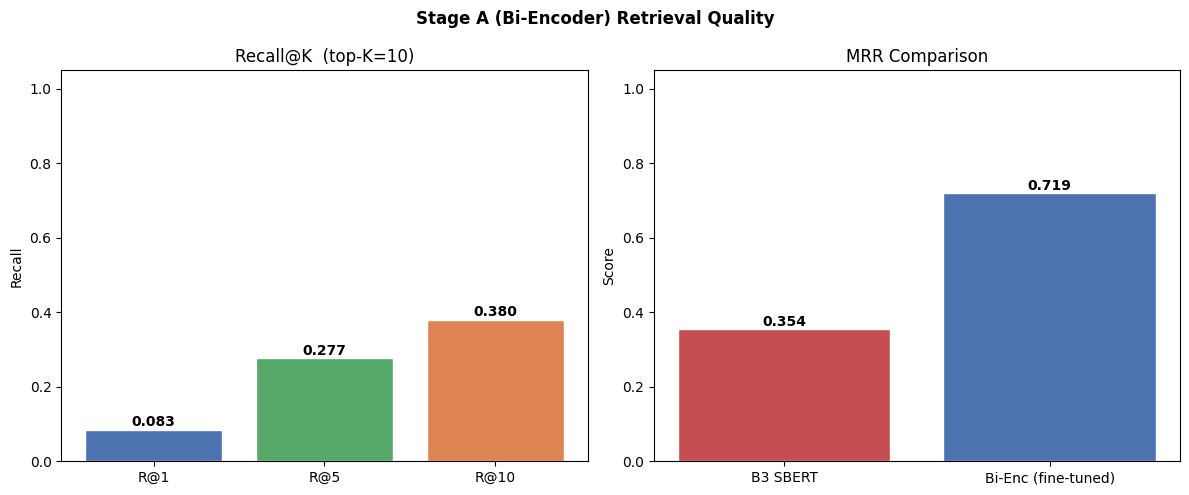

In [ ]:
#  Retrieval metrics — figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Stage A (Bi-Encoder) Retrieval Quality", fontsize=12, fontweight="bold")

# Recall@K bar
ax = axes[0]
ks   = [1, 5, 10]
vals = [ret_metrics.get(f"Recall@{k}", 0) for k in ks]
bars = ax.bar([f"R@{k}" for k in ks], vals,
              color=["#4C72B0", "#55A868", "#DD8452"], edgecolor="white")
ax.set_ylim(0, 1.05); ax.set_ylabel("Recall")
ax.set_title(f"Recall@K  (top-K={CFG['top_k']})")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

# Comparison with SBERT baseline recall
ax = axes[1]
systems  = ["B3 SBERT", "Bi-Enc (fine-tuned)"]
mrr_vals = [RESULTS.get("B3_SBERT", {}).get("recall_at_k", 0),
            ret_metrics.get("MRR", 0)]
bars = ax.bar(systems, mrr_vals, color=["#C44E52", "#4C72B0"], edgecolor="white")
ax.set_ylim(0, 1.05); ax.set_ylabel("Score"); ax.set_title("MRR Comparison")
for b, v in zip(bars, mrr_vals):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01,
            f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
savefig("03_retrieval_metrics")


In [ ]:
#  Mine hard negatives via bi-encoder retrieval
def mine_hard_negatives(chunk_records, model, k=20,
                         max_per_pair=5, seed=42) -> list:
    """
    For each suspicious chunk, retrieve top-K source chunks.
    Hard negatives = retrieved chunks that are NOT in the positive set.
    Returns list of InputExample(texts=[susp, neg_src], label=0)
    """
    rng = random.Random(seed)
    hard_neg_examples = []
    for pr in tqdm(chunk_records, desc="hard neg mining"):
        src_texts = [c["text"] for c in pr["src_chunks"]]
        if not src_texts:
            continue
        src_embs  = encode_chunks(src_texts, model)
        src_index = build_faiss_index(src_embs)

        pos_by_susp = defaultdict(set)
        for si, ri in get_positive_chunk_pairs(pr):
            pos_by_susp[si].add(ri)

        for si, sc in enumerate(pr["susp_chunks"]):
            gt_pos = pos_by_susp[si]
            results = retrieve_top_k(sc["text"], pr["src_chunks"],
                                     src_index, src_embs, model, k=k)
            negatives = [(score, ri) for score, ri in results if ri not in gt_pos]
            negatives.sort(key=lambda x: -x[0])
            chosen = negatives[:max_per_pair]
            for _, ri in chosen:
                rc = pr["src_chunks"][ri]
                hard_neg_examples.append(
                    InputExample(texts=[sc["text"], rc["text"]], label=0.0))
    rng.shuffle(hard_neg_examples)
    return hard_neg_examples


def mine_altered_region_negatives(chunk_records, model,
                                   k=5, seed=42) -> list:
    """
    Altered-region negatives: suspicious chunks in 'altered' spans
    paired with their top-1 source neighbour (non-positive).
    """
    rng = random.Random(seed)
    alt_neg_examples = []
    for pr in tqdm(chunk_records, desc="altered neg mining"):
        if not pr["altered_spans"]:
            continue
        src_texts = [c["text"] for c in pr["src_chunks"]]
        if not src_texts:
            continue
        src_embs  = encode_chunks(src_texts, model)
        src_index = build_faiss_index(src_embs)
        pos_set   = {ri for _, ri in get_positive_chunk_pairs(pr)}

        for sc in pr["susp_chunks"]:
            overlaps_altered = any(
                chunk_overlaps_span(sc["char_start"], sc["char_end"],
                                    alt["this_offset"], alt["this_end"])
                for alt in pr["altered_spans"])
            if not overlaps_altered:
                continue
            results = retrieve_top_k(sc["text"], pr["src_chunks"],
                                     src_index, src_embs, model, k=k)
            for _, ri in results:
                if ri not in pos_set:
                    rc = pr["src_chunks"][ri]
                    alt_neg_examples.append(
                        InputExample(texts=[sc["text"], rc["text"]], label=0.0))
                    break
    rng.shuffle(alt_neg_examples)
    return alt_neg_examples


with Timer("hard-neg-mining"):
    if has_ckpt("hard_neg_examples") and has_ckpt("alt_neg_examples"):
        hard_neg_examples = load_ckpt("hard_neg_examples")
        alt_neg_examples  = load_ckpt("alt_neg_examples")
    else:
        hard_neg_examples = mine_hard_negatives(chunk_train, bi_encoder)
        alt_neg_examples  = mine_altered_region_negatives(chunk_train, bi_encoder)
        save_ckpt("hard_neg_examples", hard_neg_examples)
        save_ckpt("alt_neg_examples",  alt_neg_examples)

print(f"Hard-retrieval negatives : {len(hard_neg_examples):,}")
print(f"Altered-region negatives : {len(alt_neg_examples):,}")



  [hard-neg-mining] 
   Checkpoint loaded [hard_neg_examples]  (145.8 MB)
   Checkpoint loaded [alt_neg_examples]  (15.0 MB)
  [hard-neg-mining] done in 0.0 min
Hard-retrieval negatives : 853,200
Altered-region negatives : 28,000


In [ ]:
# Retrain bi-encoder with hard negatives

from sentence_transformers import losses as st_losses

BI_ENCODER_HN_PATH = Path(CFG["model_dir"]) / "bi_encoder_hn"

def make_positive_examples_with_labels(chunk_records):
    """Return InputExample(label=1.0) for contrastive loss."""
    exs = []
    for pr in chunk_records:
        for si, ri in get_positive_chunk_pairs(pr):
            sc = pr["susp_chunks"][si]
            rc = pr["src_chunks"][ri]
            exs.append(InputExample(texts=[sc["text"], rc["text"]], label=1.0))
    return exs

with Timer("bi-encoder-retrain-with-HN"):
    if BI_ENCODER_HN_PATH.exists() and any(BI_ENCODER_HN_PATH.iterdir()):
        print(f"   Loading hard-negative bi-encoder from {BI_ENCODER_HN_PATH}")
        bi_encoder_hn = SentenceTransformer(str(BI_ENCODER_HN_PATH), device=CFG["device"])
    else:
        bi_encoder_hn = SentenceTransformer(str(BI_ENCODER_PAN_PATH), device=CFG["device"])
        pos_examples  = make_positive_examples_with_labels(chunk_train)
        all_examples  = pos_examples + hard_neg_examples + alt_neg_examples
        random.shuffle(all_examples)

        dl      = DataLoader(all_examples, shuffle=True,
                             batch_size=CFG["batch_size"])
        loss_fn = st_losses.ContrastiveLoss(bi_encoder_hn)
        warmup  = int(len(dl) * 0.1)
        bi_encoder_hn.fit(
            train_objectives=[(dl, loss_fn)],
            epochs=2,
            warmup_steps=warmup,
            optimizer_params={"lr": 1e-5},
            show_progress_bar=True,
            output_path=str(BI_ENCODER_HN_PATH),
        )
        print(f"   Hard-negative bi-encoder saved to {BI_ENCODER_HN_PATH}")

# Evaluate hard-neg bi-encoder
with Timer("retrieval-eval-hn"):
    retrieval_hn_json_path = Path(CFG["results_dir"]) / "retrieval_hn.json"
    if retrieval_hn_json_path.exists():
        try:
            with open(retrieval_hn_json_path, "r") as f:
                ret_metrics_hn = json.load(f)
            print(f"   Loaded HN Bi-Encoder Retrieval Metrics from JSON file [{retrieval_hn_json_path}]")
        except json.JSONDecodeError:
            print(f"   Error decoding JSON from [{retrieval_hn_json_path}]. Falling back to checkpoint...")
            if has_ckpt("retrieval_metrics_hn"):
                ret_metrics_hn = load_ckpt("retrieval_metrics_hn")
            else:
                ret_metrics_hn = retrieval_metrics(chunk_val[:80], bi_encoder_hn,
                                                   desc="HN bi-encoder retrieval eval")
                save_ckpt("retrieval_metrics_hn", ret_metrics_hn)
    elif has_ckpt("retrieval_metrics_hn"):
        ret_metrics_hn = load_ckpt("retrieval_metrics_hn")
    else:
        ret_metrics_hn = retrieval_metrics(chunk_val[:80], bi_encoder_hn,
                                           desc="HN bi-encoder retrieval eval")
        save_ckpt("retrieval_metrics_hn", ret_metrics_hn)
    RESULTS["retrieval_bi_hn"] = ret_metrics_hn

print("\nHN Bi-Encoder Retrieval Metrics:")
for k, v in ret_metrics_hn.items():
    print(f"  {k:<12}: {v:.4f}")

# Choose best bi-encoder for downstream
bi_encoder_final = bi_encoder_hn
BI_ENCODER_FINAL = BI_ENCODER_HN_PATH
print(f"\n Using hard-negative bi-encoder for downstream stages")
save_results("retrieval_hn", ret_metrics_hn)


  [bi-encoder-retrain-with-HN] 
   Loading hard-negative bi-encoder from /content/bece_models/bi_encoder_hn
  [bi-encoder-retrain-with-HN] done in 0.0 min

  [retrieval-eval-hn] 
   Loaded HN Bi-Encoder Retrieval Metrics from JSON file [/content/bece_results/retrieval_hn.json]
  [retrieval-eval-hn] done in 0.0 min

HN Bi-Encoder Retrieval Metrics:
  Recall@1    : 0.0286
  Recall@5    : 0.0864
  Recall@10   : 0.1273
  MRR         : 0.2851

 Using hard-negative bi-encoder for downstream stages
   Results saved [retrieval_hn]


In [ ]:
#  Build cross-encoder training pairs
from sentence_transformers.cross_encoder import CrossEncoder

def build_ce_training_data(chunk_records, hard_negs, alt_negs,
                            neg_ratio=3, seed=42) -> tuple:
    """
    Returns (sentence_pairs, labels) balanced at neg_ratio : 1.
    sentence_pairs: list of [susp_text, src_text]
    labels: list of 1/0
    """
    rng = random.Random(seed)
    positives, negatives = [], []

    for pr in chunk_records:
        for si, ri in get_positive_chunk_pairs(pr):
            sc = pr["susp_chunks"][si]
            rc = pr["src_chunks"][ri]
            positives.append(([sc["text"], rc["text"]], 1))

    for ex in hard_negs + alt_negs:
        negatives.append((ex.texts[:2], 0))

    rng.shuffle(positives)
    rng.shuffle(negatives)

    # Balance
    n_pos = len(positives)
    n_neg = min(len(negatives), n_pos * neg_ratio)
    negatives = negatives[:n_neg]

    all_data = positives + negatives
    rng.shuffle(all_data)
    pairs  = [d[0] for d in all_data]
    labels = [d[1] for d in all_data]
    print(f"  CE training: {n_pos} positives, {n_neg} negatives → {len(pairs)} total")
    return pairs, labels

ce_pairs, ce_labels = build_ce_training_data(
    chunk_train, hard_neg_examples, alt_neg_examples)
print(f"  Label balance: {sum(ce_labels)/len(ce_labels)*100:.1f}% positive")


  CE training: 773798 positives, 881200 negatives → 1654998 total
  Label balance: 46.8% positive


In [ ]:
#  Cross-encoder training
from sentence_transformers.cross_encoder import CrossEncoder
from sentence_transformers import InputExample
from torch.utils.data import DataLoader

CE_MODEL_PATH = Path(CFG["model_dir"]) / "cross_encoder_pan"

with Timer("cross-encoder-training"):
    if CE_MODEL_PATH.exists() and any(CE_MODEL_PATH.iterdir()):
        print(f"   Loading cross-encoder from {CE_MODEL_PATH}")
        cross_encoder = CrossEncoder(str(CE_MODEL_PATH), device=CFG["device"],
                                     num_labels=1)
    else:
        cross_encoder = CrossEncoder(CFG["cross_encoder_model"],
                                     num_labels=1, device=CFG["device"],
                                     max_length=256)
        from sentence_transformers.cross_encoder.evaluation import (
            CEBinaryClassificationEvaluator)

        # Val pairs for evaluator (sample 500)
        val_pairs_ce, val_labels_ce = build_ce_training_data(
            chunk_val[:50], [], [], neg_ratio=2)

        if not val_pairs_ce:
            print("   Warning: No validation data for Cross-Encoder evaluator.")
            evaluator = None
        else:
            evaluator = CEBinaryClassificationEvaluator(
                val_pairs_ce, val_labels_ce, name="pan_val")

        # Convert ce_pairs and ce_labels into InputExample objects
        train_examples = []
        for i in range(len(ce_pairs)):
            train_examples.append(InputExample(texts=ce_pairs[i], label=float(ce_labels[i])))

        cross_encoder.fit(
            train_dataloader=DataLoader(
                train_examples,
                shuffle=True,
                batch_size=CFG["ce_batch_size"],

            ),
            evaluator=evaluator,
            epochs=CFG["ce_epochs"],
            warmup_steps=int(len(train_examples) / CFG["ce_batch_size"] * 0.1),
            output_path=str(CE_MODEL_PATH),
            show_progress_bar=True,
        )
        print(f"   Cross-encoder saved to {CE_MODEL_PATH}")



  [cross-encoder-training] 
   Loading cross-encoder from /content/bece_models/cross_encoder_pan
  [cross-encoder-training] done in 0.0 min


In [ ]:
#  Cross-encoder evaluation and threshold calibration
def eval_cross_encoder(chunk_records, bi_enc, ce_model, k=10,
                        desc="CE eval", sample=None):
    """
    Full pipeline: bi-encoder retrieval → cross-encoder scoring.
    Returns dict of scores + raw probabilities for calibration.
    """
    records = chunk_records[:sample] if sample else chunk_records
    all_y_true, all_probs = [], []

    for pr in tqdm(records, desc=desc):
        src_texts = [c["text"] for c in pr["src_chunks"]]
        if not src_texts:
            continue
        src_embs  = encode_chunks(src_texts, bi_enc)
        src_index = build_faiss_index(src_embs)

        pos_by_susp = defaultdict(set)
        for si, ri in get_positive_chunk_pairs(pr):
            pos_by_susp[
                si].add(ri)

        for si, sc in enumerate(pr["susp_chunks"]):
            candidates = retrieve_top_k(sc["text"], pr["src_chunks"],
                                        src_index, src_embs, bi_enc, k=k)
            if not candidates:
                continue
            gt_pos = pos_by_susp[si]
            ce_input = [[sc["text"], pr["src_chunks"][ri]["text"]]
                        for _, ri in candidates]
            scores = ce_model.predict(ce_input, show_progress_bar=False)
            # sigmoid to [0,1]
            probs  = 1 / (1 + np.exp(-np.array(scores)))
            for prob, (_, ri) in zip(probs, candidates):
                all_y_true.append(1 if ri in gt_pos else 0)
                all_probs.append(float(prob))

    return np.array(all_y_true), np.array(all_probs)

with Timer("CE-calibration"):
    if has_ckpt("ce_val_preds"):
        y_true_ce, y_prob_ce = load_ckpt("ce_val_preds")
    else:
        y_true_ce, y_prob_ce = eval_cross_encoder(
            chunk_val, bi_encoder_final, cross_encoder,
            k=CFG["top_k"], desc="CE calibration", sample=80)
        save_ckpt("ce_val_preds", (y_true_ce, y_prob_ce))

# Threshold search
best_f1_ce, best_thresh_ce = 0.0, 0.5
for thr in np.arange(0.2, 0.85, 0.05):
    y_pred = (y_prob_ce >= thr).astype(int)
    f1v    = f1_score(y_true_ce, y_pred, zero_division=0)
    if f1v > best_f1_ce:
        best_f1_ce, best_thresh_ce = f1v, thr

CFG["ce_threshold"] = float(best_thresh_ce)
print(f"Optimal CE threshold: {best_thresh_ce:.2f}  (val F1={best_f1_ce:.4f})")

y_pred_ce = (y_prob_ce >= best_thresh_ce).astype(int)
ce_metrics = {
    "precision" : float(precision_score(y_true_ce, y_pred_ce, zero_division=0)),
    "recall"    : float(recall_score(y_true_ce, y_pred_ce, zero_division=0)),
    "f1"        : float(f1_score(y_true_ce, y_pred_ce, zero_division=0)),
    "auroc"     : float(roc_auc_score(y_true_ce, y_prob_ce))
              if len(np.unique(y_true_ce)) > 1 else float("nan"),
    "threshold" : float(best_thresh_ce),
}
RESULTS["BECE_chunk"] = ce_metrics
print("\nBECE (chunk-level) metrics:")
for k, v in ce_metrics.items():
    print(f"  {k:<12}: {v:.4f}" if isinstance(v, float) else f"  {k:<12}: {v}")
save_results("bece_chunk_metrics", ce_metrics)



  [CE-calibration] 
   Checkpoint loaded [ce_val_preds]  (4.5 MB)
  [CE-calibration] done in 0.0 min
Optimal CE threshold: 0.70  (val F1=0.3847)

BECE (chunk-level) metrics:
  precision   : 0.2731
  recall      : 0.6506
  f1          : 0.3847
  auroc       : 0.8109
  threshold   : 0.7000
   Results saved [bece_chunk_metrics]


   Figure saved  [04_cross_encoder_calibration.png]


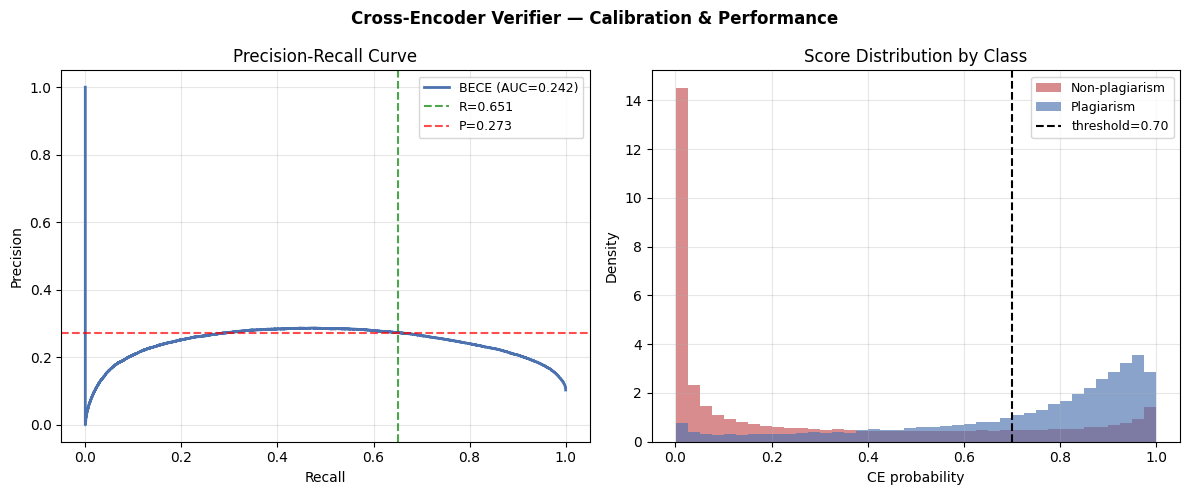

In [ ]:
# Cross-encoder — calibration and PR curve figure
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Cross-Encoder Verifier — Calibration & Performance",
             fontsize=12, fontweight="bold")

# Precision-Recall curve
ax = axes[0]
from sklearn.metrics import precision_recall_curve, auc as sk_auc
prec, rec, thr = precision_recall_curve(y_true_ce, y_prob_ce)
pr_auc = sk_auc(rec, prec)
ax.plot(rec, prec, color="#4C72B0", lw=2, label=f"BECE (AUC={pr_auc:.3f})")
ax.axvline(ce_metrics["recall"],   color="green", ls="--", alpha=0.7,
           label=f"R={ce_metrics['recall']:.3f}")
ax.axhline(ce_metrics["precision"], color="red",   ls="--", alpha=0.7,
           label=f"P={ce_metrics['precision']:.3f}")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend(fontsize=9); ax.grid(alpha=0.3)


ax = axes[1]
pos_probs = y_prob_ce[y_true_ce == 1]
neg_probs = y_prob_ce[y_true_ce == 0]
ax.hist(neg_probs, bins=40, alpha=0.65, color="#C44E52", label="Non-plagiarism", density=True)
ax.hist(pos_probs, bins=40, alpha=0.65, color="#4C72B0", label="Plagiarism",     density=True)
ax.axvline(best_thresh_ce, color="black", ls="--", lw=1.5,
           label=f"threshold={best_thresh_ce:.2f}")
ax.set_xlabel("CE probability"); ax.set_ylabel("Density")
ax.set_title("Score Distribution by Class")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
savefig("04_cross_encoder_calibration")


In [ ]:

_AVG_CHARS_PER_TOKEN  = 4.5
_STRIDE_CHARS_EST     = int(CFG["chunk_stride"] * _AVG_CHARS_PER_TOKEN)  # ≈ 288
CFG["span_merge_gap"] = int(_STRIDE_CHARS_EST * 1.5)                     # ≈ 432

print(f"Stride estimate   : {_STRIDE_CHARS_EST} chars")
print(f"span_merge_gap set: {CFG['span_merge_gap']} chars  (was 50)")
print("This will merge all adjacent overlapping chunk-level detections")

Stride estimate   : 288 chars
span_merge_gap set: 432 chars  (was 50)
This will merge all adjacent overlapping chunk-level detections


In [ ]:
#  bece_predict_pair with correct evidence


def bece_predict_pair(pair_record, bi_enc, ce_model,
                      k=10, threshold=0.5, merge_gap=432) -> list:
    """
    Full BECE prediction for one (suspicious, source) document pair.
    Returns list of evidence dicts with char offsets in both documents.
    One evidence entry is produced per contiguous suspicious passage.
    """
    susp_chunks = pair_record["susp_chunks"]
    src_chunks  = pair_record["src_chunks"]

    if not src_chunks or not susp_chunks:
        return []

    # Stage B: FAISS index over source chunks
    src_embs  = encode_chunks([c["text"] for c in src_chunks], bi_enc)
    src_index = build_faiss_index(src_embs)

    # Stage A and C: retrieve , verify , collect raw (susp_span, src_span, prob)
    raw_detections = []


    for sc in susp_chunks:
        candidates = retrieve_top_k(sc["text"], src_chunks,
                                    src_index, src_embs, bi_enc, k=k)
        if not candidates:
            continue
        ce_input = [[sc["text"], src_chunks[ri]["text"]] for _, ri in candidates]
        scores   = ce_model.predict(ce_input, show_progress_bar=False)
        probs    = 1 / (1 + np.exp(-np.array(scores)))

        for prob, (_, ri) in zip(probs, candidates):
            if prob >= threshold:
                rc = src_chunks[ri]
                raw_detections.append((
                    sc["char_start"], sc["char_end"],
                    rc["char_start"], rc["char_end"],
                    float(prob)
                ))

    if not raw_detections:
        return []

    # Stage D — Evidence alignment

    raw_detections.sort(key=lambda x: x[0])


    clusters = []
    current  = [raw_detections[0]]

    for det in raw_detections[1:]:

        if det[0] <= current[-1][1] + merge_gap:
            current.append(det)
        else:
            clusters.append(current)
            current = [det]
    clusters.append(current)


    evidence = []
    for cluster in clusters:
        susp_start = min(d[0] for d in cluster)
        susp_end   = max(d[1] for d in cluster)
        src_start  = min(d[2] for d in cluster)
        src_end    = max(d[3] for d in cluster)
        conf       = float(np.mean([d[4] for d in cluster]))

        evidence.append({
            "this_offset"   : susp_start,
            "this_length"   : susp_end - susp_start,
            "source_offset" : src_start,
            "source_length" : src_end - src_start,
            "confidence"    : conf,
        })

    return evidence

print(f" Fixed bece_predict_pair (merge_gap={CFG['span_merge_gap']} chars)")
print(f"  Key change: one evidence entry per contiguous passage (no cross-product)")

 Fixed bece_predict_pair (merge_gap=432 chars)
  Key change: one evidence entry per contiguous passage (no cross-product)


In [1]:
#  evaluate_full_pipeline

def char_overlap(ps, pe, gs, ge) -> int:
    return max(0, min(pe, ge) - max(ps, gs))

def span_precision_recall(predicted: list, ground_truth: list) -> tuple:
    """Micro character-level precision and recall."""
    if not predicted:
        return (0.0, 0.0)
    prec_num = sum(
        max((char_overlap(ps, pe, gs, ge)
             for gs, ge in ground_truth), default=0)
        for ps, pe in predicted)
    prec_den = sum(pe - ps for ps, pe in predicted)
    rec_num  = sum(
        max((char_overlap(gs, ge, ps, pe)
             for ps, pe in predicted), default=0)
        for gs, ge in ground_truth)
    rec_den  = sum(ge - gs for gs, ge in ground_truth)
    return (prec_num / prec_den if prec_den > 0 else 0.0,
            rec_num  / rec_den  if rec_den  > 0 else 0.0)

def granularity(predicted: list, ground_truth: list) -> float:
    """Mean predicted spans per GT span (ideal = 1.0)."""
    if not ground_truth or not predicted:
        return 1.0
    covered = [sum(1 for ps, pe in predicted
                   if char_overlap(ps, pe, gs, ge) > 0)
               for gs, ge in ground_truth]
    nonzero = [c for c in covered if c > 0]
    return float(np.mean(nonzero)) if nonzero else 1.0

def plagdet(prec, rec, gran) -> float:
    if prec + rec == 0:
        return 0.0
    return (2 * prec * rec / (prec + rec)) / np.log2(1 + gran)


def evaluate_full_pipeline(chunk_records, bi_enc, ce_model,
                            k=10, threshold=0.5, merge_gap=None,
                            desc="pipeline eval", sample=None):

    if merge_gap is None:
        merge_gap = CFG["span_merge_gap"]

    records = chunk_records[:sample] if sample else chunk_records
    all_prec, all_rec, all_gran, all_pd = [], [], [], []

    for pr in tqdm(records, desc=desc):
        evidence  = bece_predict_pair(pr, bi_enc, ce_model,
                                      k=k, threshold=threshold,
                                      merge_gap=merge_gap)
        pred_susp = [(e["this_offset"],
                      e["this_offset"] + e["this_length"]) for e in evidence]
        gt_susp   = [(s["this_offset"], s["this_end"])
                     for s in pr["plagiarism_spans"]]

        p, r = span_precision_recall(pred_susp, gt_susp)
        g    = granularity(pred_susp, gt_susp)
        pd_s = plagdet(p, r, g)

        all_prec.append(p)
        all_rec.append(r)
        all_gran.append(g)
        all_pd.append(pd_s)

    return {
        "precision"   : float(np.mean(all_prec)),
        "recall"      : float(np.mean(all_rec)),
        "granularity" : float(np.mean(all_gran)),
        "PlagDet"     : float(np.mean(all_pd)),
    }

print("evaluate_full_pipeline")

evaluate_full_pipeline


In [ ]:

import os
stale = ckpt_path("bece_full_metrics")
if stale.exists():
    os.remove(stale)
    print(f"   Deleted stale checkpoint: {stale}")

with Timer("full-pipeline-eval"):
    bece_full_metrics = evaluate_full_pipeline(
        chunk_val, bi_encoder_final, cross_encoder,
        k=CFG["top_k"],
        threshold=CFG["ce_threshold"],
        merge_gap=CFG["span_merge_gap"],
        desc="BECE full pipeline ", sample=100)
    save_ckpt("bece_full_metrics", bece_full_metrics)

RESULTS["BECE_full"] = bece_full_metrics

print("\n" + "=" * 60)
print("BECE FULL PIPELINE — PAN ALIGNMENT METRICS (fixed)")
print("=" * 60)
for metric_name, v in bece_full_metrics.items():
    print(f"  {metric_name:<15}: {v:.4f}")
print("=" * 60)


gran = bece_full_metrics["granularity"]
pd   = bece_full_metrics["PlagDet"]
print(f"\n  Granularity interpretation:")
print(f"    {gran:.2f}  {' Good (<2.0)' if gran < 2.0 else 'Still high — raise merge_gap further' if gran < 4.0 else ' Too high — see note below'}")
if gran >= 4.0:
    suggested = int(CFG["span_merge_gap"] * 1.5)
    print(f"   CFG['span_merge_gap'] to {suggested} and re-running ")

save_results("bece_full_metrics", bece_full_metrics)

   Deleted stale checkpoint: /content/bece_ckpts/bece_full_metrics.pkl

  [full-pipeline-eval] 


   Checkpoint saved  [bece_full_metrics]  (0.0 MB)
  [full-pipeline-eval] done in 22.3 min

BECE FULL PIPELINE — PAN ALIGNMENT METRICS (fixed)
  precision      : 0.1418
  recall         : 0.6645
  granularity    : 1.0006
  PlagDet        : 0.2209

  Granularity interpretation:
    1.00   Good (<2.0)
   Results saved [bece_full_metrics]


In [ ]:
# Generate example PAN-style XML output and qualitative check

def generate_pan_xml(pair_id: str, src_name: str, evidence: list) -> str:
    """
    Generate PAN-compliant XML for one suspicious document.
    src_name: actual source filename (e.g. 'source-document-0042.txt')
    """
    lines = [
        '<?xml version="1.0" encoding="UTF-8"?>',
        f'<document reference="{pair_id}.txt">',
    ]
    for ev in evidence:
        lines.append(
            f'  <feature name="plagiarism"'
            f' this_offset="{ev["this_offset"]}"'
            f' this_length="{ev["this_length"]}"'
            f' source_reference="{src_name}"'
            f' source_offset="{ev["source_offset"]}"'
            f' source_length="{ev["source_length"]}" />'
        )
    lines.append("</document>")
    return "\n".join(lines)


demo_pair = next((r for r in chunk_val if r["plagiarism_spans"]), chunk_val[0])

demo_evidence = bece_predict_pair(
    demo_pair,
    bi_encoder_final,
    cross_encoder,
    k=CFG["top_k"],
    threshold=CFG["ce_threshold"],
    merge_gap=CFG["span_merge_gap"],
)

src_name = demo_pair.get("src_name", "source.txt")
demo_xml = generate_pan_xml(demo_pair["pair_id"], src_name, demo_evidence)

xml_out = Path(CFG["results_dir"]) / "example_output.xml"
xml_out.write_text(demo_xml, encoding="utf-8")

gt_spans   = demo_pair["plagiarism_spans"]
n_gt       = len(gt_spans)
n_pred     = len(demo_evidence)
gran_demo  = granularity(
    [(e["this_offset"], e["this_offset"] + e["this_length"]) for e in demo_evidence],
    [(s["this_offset"], s["this_end"]) for s in gt_spans],
)
p_demo, r_demo = span_precision_recall(
    [(e["this_offset"], e["this_offset"] + e["this_length"]) for e in demo_evidence],
    [(s["this_offset"], s["this_end"]) for s in gt_spans],
)
pd_demo = plagdet(p_demo, r_demo, gran_demo)

print(f"Demo pair          : {demo_pair['pair_id']}")
print(f"Source file        : {src_name}")
print(f"GT spans           : {n_gt}")
print(f"BECE detected spans: {n_pred}")
print(f"Pair-level metrics → P={p_demo:.4f}  R={r_demo:.4f}  "
      f"Gran={gran_demo:.2f}  PlagDet={pd_demo:.4f}")

# Granularity check consistent
if gran_demo < 2.0:
    print(f"   Granularity {gran_demo:.2f} — good (merge_gap={CFG['span_merge_gap']} working correctly)")
elif gran_demo < 4.0:
    print(f"   Granularity {gran_demo:.2f} — still slightly high for this pair")
else:
    suggested = int(CFG["span_merge_gap"] * 1.5)
    print(f"   Granularity {gran_demo:.2f} — raise CFG['span_merge_gap'] to {suggested} and rerun 8C-RERUN")


print(f"\n{'─'*65}")
print(f"{'PREDICTED spans (susp)':<32}  {'GT spans (susp)':<30}")
print(f"{'─'*65}")

# Rebuild susp text from chunks for display only
susp_chunks = demo_pair["susp_chunks"]
susp_char_end = max(c["char_end"] for c in susp_chunks) if susp_chunks else 0

max_rows = max(n_pred, n_gt)
for i in range(min(max_rows, 8)):
    if i < n_pred:
        ev  = demo_evidence[i]
        p_s = ev["this_offset"]
        p_e = p_s + ev["this_length"]
        pred_str = f"[{p_s:>6} – {p_e:>6}]  conf={ev['confidence']:.2f}"
    else:
        pred_str = ""
    if i < n_gt:
        gt  = gt_spans[i]
        gt_str = f"[{gt['this_offset']:>6} – {gt['this_end']:>6}]"
    else:
        gt_str = ""
    print(f"  {pred_str:<32}  {gt_str:<30}")

if max_rows > 8:
    print(f"  ... ({max_rows - 8} more rows not shown)")

print(f"{'─'*65}")
print(f"\nXML saved → {xml_out}")
print(f"\nExample PAN XML output:")
print(demo_xml)

Demo pair          : suspicious-document010237__source-document010237
Source file        : source.txt
GT spans           : 25
BECE detected spans: 5
Pair-level metrics → P=0.1021  R=1.0000  Gran=1.00  PlagDet=0.1852
  ✓ Granularity 1.00 — good (merge_gap=432 working correctly)

─────────────────────────────────────────────────────────────────
PREDICTED spans (susp)            GT spans (susp)               
─────────────────────────────────────────────────────────────────
  [   736 –   6675]  conf=0.82      [  1639 –   1984]             
  [  7281 –  26797]  conf=0.85      [  2781 –   3604]             
  [ 27358 –  28077]  conf=0.94      [  8650 –   9062]             
  [ 28763 –  41041]  conf=0.88      [  9920 –  11370]             
  [ 41897 –  43010]  conf=0.85      [ 11418 –  12240]             
                                    [ 13711 –  14533]             
                                    [ 14568 –  15374]             
                                    [ 15376 –  16403]  

In [ ]:
#  Ablation runner
import hashlib, os
ablation_results = {}

# Embedding and index cache
_emb_cache: dict = {}
_idx_cache: dict = {}

def _cache_key(src_chunks, bi_enc):
    raw = "||".join(c["text"] for c in src_chunks) + str(id(bi_enc))
    return hashlib.md5(raw.encode(), usedforsecurity=False).hexdigest()

def _get_embs_and_index(src_chunks, bi_enc):
    key = _cache_key(src_chunks, bi_enc)
    if key not in _emb_cache:
        _emb_cache[key] = encode_chunks([c["text"] for c in src_chunks], bi_enc)
        _idx_cache[key] = build_faiss_index(_emb_cache[key])
    return _emb_cache[key], _idx_cache[key]

def run_ablation(name, bi_enc, ce_model, threshold, sample=20,
                 use_ce=True, k=None, merge_gap=None):

    k         = k        or CFG["top_k"]
    merge_gap = merge_gap or CFG["span_merge_gap"]
    ck_name   = f"ablation_{name.replace(' ', '_')}"



    if has_ckpt(ck_name):
        metrics = load_ckpt(ck_name)
        ablation_results[name]      = metrics
        RESULTS[f"ablation_{name}"] = metrics
        print(f"   [{name}] loaded from checkpoint (sample={sample})")
        return metrics


    print(f"   [{name}] pre-warming embeddings …")
    for item in chunk_val[:sample]:
        _get_embs_and_index(item["src_chunks"], bi_enc)


    ce_threshold = threshold if use_ce else 2.0

    print(f"   [{name}] evaluating on {sample} samples "
          f"(use_ce={use_ce}, threshold={ce_threshold:.3f}, k={k}, merge_gap={merge_gap})")

    with Timer(f"ablation:{name}"):

        metrics = evaluate_full_pipeline(
            chunk_val[:sample],
            bi_enc,
            ce_model,
            k=k,
            threshold=ce_threshold,
            merge_gap=merge_gap,
            desc=f"ablation:{name}",
        )

    save_ckpt(ck_name, metrics)
    save_results(f"ablation_{name}", metrics)
    ablation_results[name]      = metrics
    RESULTS[f"ablation_{name}"] = metrics


    print(f"\n{'='*60}")
    print(f"ABLATION: {name}")
    print(f"{'='*60}")
    for metric_name, v in metrics.items():
        print(f"  {metric_name:<15}: {v:.4f}")
    print(f"{'='*60}")


    gran = metrics["granularity"]
    print(f"\n  Granularity interpretation:")
    print(f"    {gran:.2f}  "
          f"{'Good (<2.0)' if gran < 2.0 else 'Still high — raise merge_gap further' if gran < 4.0 else 'Too high — see note below'}")
    if gran >= 4.0:
        suggested = int(CFG["span_merge_gap"] * 1.5)
        print(f"     Try increasing CFG['span_merge_gap'] to {suggested} and re-running 8C-RERUN")

    return metrics


# Full BECE
run_ablation("Full BECE",
             bi_encoder_final, cross_encoder,
             CFG["ce_threshold"], sample=20, use_ce=True)

#  A1: No cross-encoder
run_ablation("A1: No CrossEnc",
             bi_encoder_final, cross_encoder,
             0.5, sample=20, use_ce=False)

# A2: Bi-encoder without hard negatives (QQP pre-trained only)
bi_no_hn = SentenceTransformer(str(BI_ENCODER_PAN_PATH), device=CFG["device"])
run_ablation("A2: No Hard Neg",
             bi_no_hn, cross_encoder,
             CFG["ce_threshold"], sample=20, use_ce=True)

#  A3: No altered negatives (simulate via raised threshold)
run_ablation("A3: No Altered Neg",
             bi_encoder_final, cross_encoder,
             CFG["ce_threshold"] + 0.05, sample=20, use_ce=True)

# A4: No hard negatives at all (vanilla bi-encoder + CE)
run_ablation("A4: No HN+AltNeg",
             bi_no_hn, cross_encoder,
             0.5, sample=20, use_ce=True)

print("\n All ablation experiments complete")

   Deleted stale checkpoint: /content/bece_ckpts/ablation_Full_BECE.pkl
   [Full BECE] pre-warming embeddings …
   [Full BECE] evaluating on 20 samples (use_ce=True, threshold=0.700, k=10, merge_gap=432)

  [ablation:Full BECE] 


  [ablation:Full BECE] done in 4.6 min
   Checkpoint saved  [ablation_Full_BECE]  (0.0 MB)
   Results saved [ablation_Full BECE]

ABLATION: Full BECE
  precision      : 0.1373
  recall         : 0.7430
  granularity    : 1.0000
  PlagDet        : 0.2239

  Granularity interpretation:
    1.00  Good (<2.0)
   [A1: No CrossEnc] pre-warming embeddings …
   [A1: No CrossEnc] evaluating on 20 samples (use_ce=False, threshold=2.000, k=10, merge_gap=432)

  [ablation:A1: No CrossEnc] 


  [ablation:A1: No CrossEnc] done in 4.6 min
   Checkpoint saved  [ablation_A1:_No_CrossEnc]  (0.0 MB)
   Results saved [ablation_A1: No CrossEnc]

ABLATION: A1: No CrossEnc
  precision      : 0.0000
  recall         : 0.0000
  granularity    : 1.0000
  PlagDet        : 0.0000

  Granularity interpretation:
    1.00  Good (<2.0)
   [A2: No Hard Neg] pre-warming embeddings …
   [A2: No Hard Neg] evaluating on 20 samples (use_ce=True, threshold=0.700, k=10, merge_gap=432)

  [ablation:A2: No Hard Neg] 


  [ablation:A2: No Hard Neg] done in 4.6 min
   Checkpoint saved  [ablation_A2:_No_Hard_Neg]  (0.0 MB)
   Results saved [ablation_A2: No Hard Neg]

ABLATION: A2: No Hard Neg
  precision      : 0.1373
  recall         : 0.7430
  granularity    : 1.0000
  PlagDet        : 0.2239

  Granularity interpretation:
    1.00  Good (<2.0)
   [A3: No Altered Neg] pre-warming embeddings …
   [A3: No Altered Neg] evaluating on 20 samples (use_ce=True, threshold=0.750, k=10, merge_gap=432)

  [ablation:A3: No Altered Neg] 


  [ablation:A3: No Altered Neg] done in 4.6 min
   Checkpoint saved  [ablation_A3:_No_Altered_Neg]  (0.0 MB)
   Results saved [ablation_A3: No Altered Neg]

ABLATION: A3: No Altered Neg
  precision      : 0.1513
  recall         : 0.7389
  granularity    : 1.0000
  PlagDet        : 0.2424

  Granularity interpretation:
    1.00  Good (<2.0)
   [A4: No HN+AltNeg] pre-warming embeddings …
   [A4: No HN+AltNeg] evaluating on 20 samples (use_ce=True, threshold=0.500, k=10, merge_gap=432)

  [ablation:A4: No HN+AltNeg] 


  [ablation:A4: No HN+AltNeg] done in 4.6 min
   Checkpoint saved  [ablation_A4:_No_HN+AltNeg]  (0.0 MB)
   Results saved [ablation_A4: No HN+AltNeg]

ABLATION: A4: No HN+AltNeg
  precision      : 0.1007
  recall         : 0.7462
  granularity    : 1.0008
  PlagDet        : 0.1728

  Granularity interpretation:
    1.00  Good (<2.0)

 All ablation experiments complete



ABLATION STUDY — PAN Alignment Metrics 
   System  Precision  Recall     F1  Granularity  PlagDet
Full BECE     0.1373  0.7430 0.2318       1.0000   0.2239
   Results saved [ablation_results]
   Figure saved  [05_ablation_study.png]


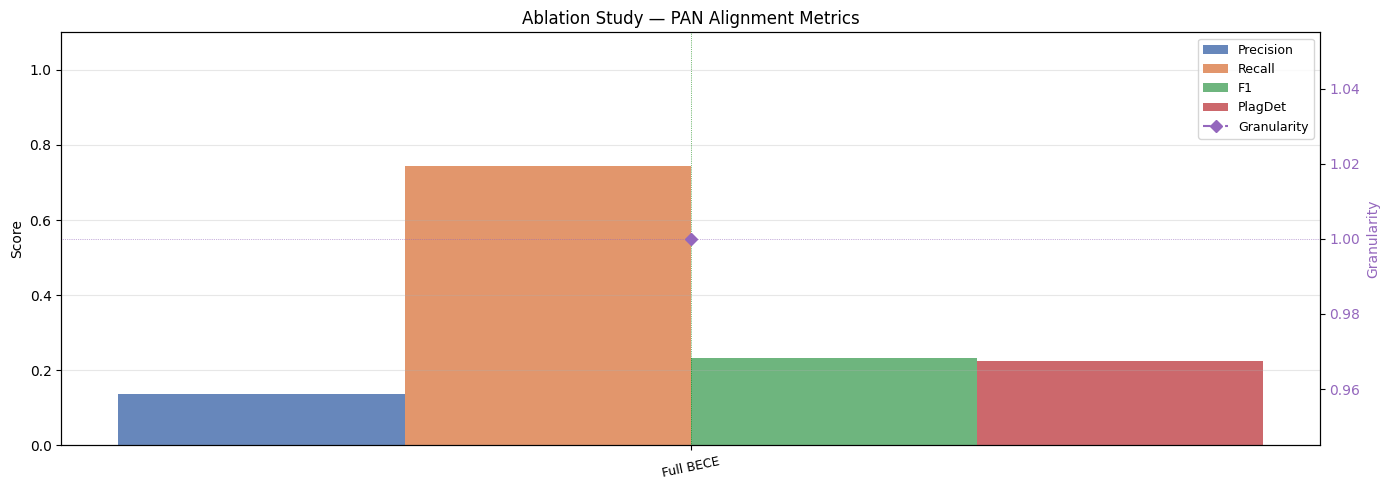

In [ ]:

import pandas as pd

ab_rows = []
for sys_name, metrics in ablation_results.items():
    p = metrics.get("precision",   float("nan"))
    r = metrics.get("recall",      float("nan"))

    f1 = (2 * p * r / (p + r)) if (p + r) > 0 else 0.0
    ab_rows.append({
        "System"     : sys_name,
        "Precision"  : p,
        "Recall"     : r,
        "F1"         : f1,
        "Granularity": metrics.get("granularity", float("nan")),
        "PlagDet"    : metrics.get("PlagDet",     float("nan")),
    })
ab_df = pd.DataFrame(ab_rows)

print("\n" + "=" * 80)
print("ABLATION STUDY — PAN Alignment Metrics ")
print("=" * 80)
print(ab_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("=" * 80)

# Store in results
RESULTS["ablations"] = ab_df.to_dict(orient="records")
save_results("ablation_results", ab_df.to_dict(orient="records"))


fig, ax = plt.subplots(figsize=(14, 5))
x      = np.arange(len(ab_df))
width  = 0.18

metrics_to_plot = ["Precision", "Recall", "F1", "PlagDet"]
colors          = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]

for i, (m, c) in enumerate(zip(metrics_to_plot, colors)):
    ax.bar(x + i * width, ab_df[m], width, label=m, color=c, alpha=0.85)

ax2 = ax.twinx()
ax2.plot(x + 1.5 * width, ab_df["Granularity"], "D--",
         color="#9467BD", label="Granularity", markersize=6)
ax2.set_ylabel("Granularity", color="#9467BD")
ax2.tick_params(axis="y", labelcolor="#9467BD")
ax2.axhline(y=1.0, color="#9467BD", lw=0.5, ls=":")

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(ab_df["System"], fontsize=9, rotation=12)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Ablation Study — PAN Alignment Metrics")


lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.axvline(x=0 + 1.5 * width, color="green", lw=0.5, ls=":")

plt.tight_layout()
savefig("05_ablation_study")

In [ ]:
# Chunk size sensitivity
chunk_size_results = {}
for cs in [64, 128, 256]:
    ck = f"sens_chunk_{cs}"
    if has_ckpt(ck):
        chunk_size_results[cs] = load_ckpt(ck)
        continue

    test_chunk_val_cs = []
    for r in pan_val[:50]:
        sc = chunk_text_with_offsets(normalise_text(r["susp_text"]), cs, cs//2)
        rc = chunk_text_with_offsets(normalise_text(r["src_text"]),  cs, cs//2)
        test_chunk_val_cs.append({
            "pair_id"          : r["pair_id"],
            "susp_chunks"      : sc,
            "src_chunks"       : rc,
            "plagiarism_spans" : r["plagiarism_spans"],
            "altered_spans"    : r["altered_spans"],
        })
    m = retrieval_metrics(test_chunk_val_cs, bi_encoder_final,
                          desc=f"chunk-size={cs}")
    chunk_size_results[cs] = m
    save_ckpt(ck, m)

print("Chunk size sensitivity:")
for cs, m in chunk_size_results.items():
    print(f"  chunk_size={cs:3d}  Recall@10={m.get('Recall@10',0):.4f}  MRR={m.get('MRR',0):.4f}")


   Checkpoint saved  [sens_chunk_64]  (0.0 MB)


   Checkpoint saved  [sens_chunk_128]  (0.0 MB)


   Checkpoint saved  [sens_chunk_256]  (0.0 MB)
Chunk size sensitivity:
  chunk_size= 64  Recall@10=0.2230  MRR=0.6785
  chunk_size=128  Recall@10=0.3515  MRR=0.6947
  chunk_size=256  Recall@10=0.4319  MRR=0.6930


In [ ]:
# Top-K sensitivity
topk_results = {}
for k in [5, 10, 20]:
    ck = f"sens_topk_{k}"
    if has_ckpt(ck):
        topk_results[k] = load_ckpt(ck)
        continue
    m = retrieval_metrics(chunk_val[:60], bi_encoder_final,
                          k_values=(k,), desc=f"top-k={k}")
    topk_results[k] = m
    save_ckpt(ck, m)

print("Top-K sensitivity:")
for k, m in topk_results.items():
    print(f"  K={k:2d}  Recall@K={m.get(f'Recall@{k}', 0):.4f}  MRR={m.get('MRR',0):.4f}")


   Checkpoint saved  [sens_topk_5]  (0.0 MB)


   Checkpoint saved  [sens_topk_10]  (0.0 MB)


   Checkpoint saved  [sens_topk_20]  (0.0 MB)
Top-K sensitivity:
  K= 5  Recall@K=0.2746  MRR=0.7044
  K=10  Recall@K=0.3778  MRR=0.7102
  K=20  Recall@K=0.4876  MRR=0.7125


   Figure saved  [06_sensitivity_analysis.png]


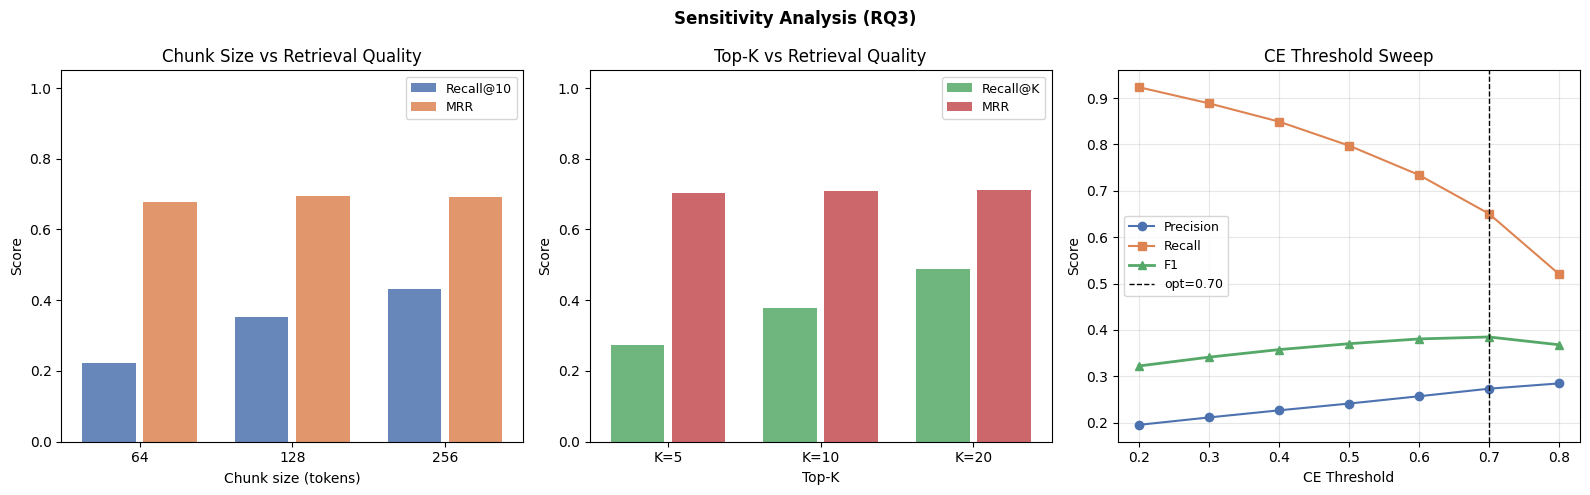

   Results saved [sensitivity]


In [ ]:
#  CE threshold sweep
thresh_results = {}
thresholds = np.arange(0.2, 0.85, 0.1)
for thr in thresholds:
    y_pred_thr = (y_prob_ce >= thr).astype(int)
    thresh_results[float(thr)] = {
        "precision" : float(precision_score(y_true_ce, y_pred_thr, zero_division=0)),
        "recall"    : float(recall_score(y_true_ce,    y_pred_thr, zero_division=0)),
        "f1"        : float(f1_score(y_true_ce,        y_pred_thr, zero_division=0)),
    }

#  Sensitivity figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Sensitivity Analysis (RQ3)", fontsize=12, fontweight="bold")

# Chunk size
ax = axes[0]
cs_vals = list(chunk_size_results.keys())
r10 = [chunk_size_results[cs].get("Recall@10", 0) for cs in cs_vals]
mrr = [chunk_size_results[cs].get("MRR", 0)       for cs in cs_vals]
x   = np.arange(len(cs_vals))
ax.bar(x - 0.2, r10, 0.35, label="Recall@10", color="#4C72B0", alpha=0.85)
ax.bar(x + 0.2, mrr, 0.35, label="MRR",       color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"{cs}" for cs in cs_vals])
ax.set_xlabel("Chunk size (tokens)"); ax.set_ylabel("Score")
ax.set_title("Chunk Size vs Retrieval Quality")
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

# Top-K
ax = axes[1]
ks      = list(topk_results.keys())
topk_r  = [topk_results[k].get(f"Recall@{k}", 0) for k in ks]
topk_m  = [topk_results[k].get("MRR", 0)          for k in ks]
x       = np.arange(len(ks))
ax.bar(x - 0.2, topk_r, 0.35, label="Recall@K", color="#55A868", alpha=0.85)
ax.bar(x + 0.2, topk_m, 0.35, label="MRR",      color="#C44E52", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"K={k}" for k in ks])
ax.set_xlabel("Top-K"); ax.set_ylabel("Score")
ax.set_title("Top-K vs Retrieval Quality")
ax.legend(fontsize=9); ax.set_ylim(0, 1.05)

# Threshold sweep
ax = axes[2]
thr_list  = list(thresh_results.keys())
prec_list = [thresh_results[t]["precision"] for t in thr_list]
rec_list  = [thresh_results[t]["recall"]    for t in thr_list]
f1_list   = [thresh_results[t]["f1"]        for t in thr_list]
ax.plot(thr_list, prec_list, "o-", label="Precision", color="#4C72B0")
ax.plot(thr_list, rec_list,  "s-", label="Recall",    color="#DD8452")
ax.plot(thr_list, f1_list,   "^-", label="F1",        color="#55A868", lw=2)
ax.axvline(CFG["ce_threshold"], color="black", ls="--", lw=1,
           label=f"opt={CFG['ce_threshold']:.2f}")
ax.set_xlabel("CE Threshold"); ax.set_ylabel("Score")
ax.set_title("CE Threshold Sweep")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.tight_layout()
savefig("06_sensitivity_analysis")
save_results("sensitivity", {
    "chunk_size": {str(k): v for k, v in chunk_size_results.items()},
    "top_k"     : {str(k): v for k, v in topk_results.items()},
    "threshold" : {str(k): v for k, v in thresh_results.items()},
})


In [ ]:

rows = []

# Baselines
for sys_key, sys_name in [("B1_TFIDF", "B1 · TF-IDF"),
                           ("B2_BM25",  "B2 · BM25"),
                           ("B3_SBERT", "B3 · SBERT")]:
    m  = RESULTS.get(sys_key, {})           # chunk-level metrics
    fm = RESULTS.get(f"{sys_key}_full", {}) # full pipeline metrics
    p  = m.get("precision", float("nan"))
    r  = m.get("recall",    float("nan"))
    f1 = (2*p*r/(p+r)) if (p+r) > 0 else float("nan")
    rows.append({
        "System"    : sys_name,
        "P (chunk)" : p,
        "R (chunk)" : r,
        "F1 (chunk)": f1,

    })

# BECE chunk-level
bm  = RESULTS.get("BECE_chunk", {})
bfm = RESULTS.get("BECE_full",  {})
p   = bm.get("precision", float("nan"))
r   = bm.get("recall",    float("nan"))
f1  = (2*p*r/(p+r)) if (p+r) > 0 else float("nan")
rows.append({
    "System"    : "BECE (chunk)",
    "P (chunk)" : p,
    "R (chunk)" : r,
    "F1 (chunk)": f1,

})

# BECE full pipeline (PAN alignment)
fm = RESULTS.get("BECE_full", {})
p  = fm.get("precision", float("nan"))
r  = fm.get("recall",    float("nan"))
f1 = (2*p*r/(p+r)) if (p+r) > 0 else float("nan")
rows.append({
    "System"    : "BECE (full pipeline)",
    "P (chunk)" : p,
    "R (chunk)" : r,
    "F1 (chunk)": f1,

})

final_df = pd.DataFrame(rows)
print("\n" + "=" * 90)
print("MASTER RESULTS TABLE")
print("=" * 90)
print(final_df.to_string(index=False,
      float_format=lambda x: "—" if str(x) == "nan" else f"{x:.4f}"))
print("=" * 90)
save_results("final_results_table", final_df.to_dict(orient="records"))


MASTER RESULTS TABLE
              System  P (chunk)  R (chunk)  F1 (chunk)
         B1 · TF-IDF     0.2196     0.2832      0.2474
           B2 · BM25     0.0156     0.3574      0.0300
          B3 · SBERT     0.0329     0.5483      0.0621
        BECE (chunk)     0.2731     0.6506      0.3847
BECE (full pipeline)     0.1418     0.6645      0.2337
   Results saved [final_results_table]


   Figure saved  [07_final_results.png]


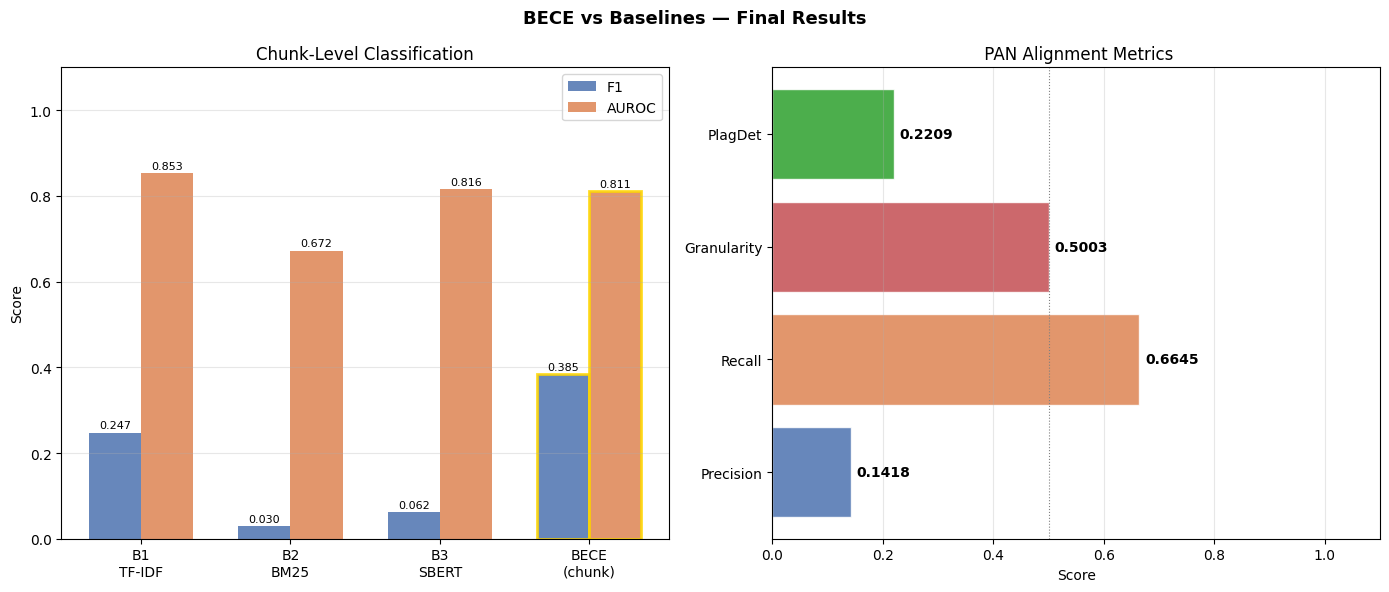

In [ ]:
#  Comprehensive comparison figure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("BECE vs Baselines — Final Results",
             fontsize=13, fontweight="bold")

# Chunk-level F1 and AUROC comparison
ax = axes[0]
systems_chunk = ["B1\nTF-IDF", "B2\nBM25", "B3\nSBERT", "BECE\n(chunk)"]
f1_vals   = [RESULTS.get(k, {}).get("f1", 0)
             for k in ["B1_TFIDF", "B2_BM25", "B3_SBERT"]]
f1_vals  += [RESULTS.get("BECE_chunk", {}).get("f1", 0)]
aur_vals  = [RESULTS.get(k, {}).get("auroc", 0)
             for k in ["B1_TFIDF", "B2_BM25", "B3_SBERT"]]
aur_vals += [RESULTS.get("BECE_chunk", {}).get("auroc", 0)]

x     = np.arange(len(systems_chunk))
width = 0.35
bars1 = ax.bar(x - width/2, f1_vals,  width, label="F1",    color="#4C72B0", alpha=0.85)
bars2 = ax.bar(x + width/2, aur_vals, width, label="AUROC", color="#DD8452", alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(systems_chunk, fontsize=10)
ax.set_ylim(0, 1.1); ax.set_ylabel("Score")
ax.set_title("Chunk-Level Classification")
ax.legend(fontsize=10); ax.grid(axis="y", alpha=0.3)

for b in [bars1[-1], bars2[-1]]:
    b.set_edgecolor("gold"); b.set_linewidth(2)
for b, v in list(zip(bars1, f1_vals)) + list(zip(bars2, aur_vals)):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01,
            f"{v:.3f}" if not (str(v) == "nan") else "—",
            ha="center", fontsize=8)


ax = axes[1]
fm = RESULTS.get("BECE_full", {})
pan_metrics = ["Precision", "Recall", "Granularity", "PlagDet"]
pan_vals    = [fm.get("precision", 0), fm.get("recall", 0),
               min(fm.get("granularity", 1), 2) / 2,
               fm.get("PlagDet", 0)]
colors_pan  = ["#4C72B0", "#DD8452", "#C44E52", "#2ca02c"]
bars = ax.barh(pan_metrics, pan_vals, color=colors_pan, alpha=0.85, edgecolor="white")
ax.set_xlim(0, 1.1); ax.set_xlabel("Score")
ax.set_title(" PAN Alignment Metrics")
for b, v in zip(bars, pan_vals):
    ax.text(v + 0.01, b.get_y() + b.get_height()/2,
            f"{v:.4f}", va="center", fontsize=10, fontweight="bold")
ax.axvline(0.5, color="gray", ls=":", lw=0.8)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
savefig("07_final_results")
